In [2]:
%load_ext autoreload
%autoreload 2
import sys
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from os.path import join
import os
import seaborn as sns

config_dir = "../../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir, google_folder_id, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Added to sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


# Goal

- Compare the performance of iForest, PCA/DPCA/MGKPCA and iForest in PCA space

# PCA Space construction

In [11]:
data_dict, extracted_dir = load_data(
    file_id=google_folder_id,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data.tar",
    pattern="*.csv",
)

list_keys = list(data_dict.keys())

Extracted data found at: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24
Loading ARAG data from: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-ARAG24


In [12]:
list_session = []
for s in list_keys:
    df = data_dict[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session.append(s)

In [13]:
len(list_session)

40

## Function to create whole dataset

In [14]:
import random

def create_session_anomaly(data_dict, session_anomaly):
    """
    Create a list of anomalous session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of anomalous session path
    session_anomaly_list = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] in session_anomaly:
            session_anomaly_list.append(s)
    
    return session_anomaly_list

def create_session_clean(data_dict, session_anomaly):
    """
    Create a list of clean session path
    """
    list_keys = list(data_dict.keys())

    # Find the list of clean session path
    session_clean = []
    for s in list_keys:
        df = data_dict[s].copy()
        if preprocessing.clean_dataframe(df).shape[0] != 0 and os.path.splitext(os.path.basename(s))[0] not in session_anomaly:
            session_clean.append(s)
    
    return session_clean


def split_session(session_clean, p=2/3, seed = None):
    """
    split the list of clean session path into train and test
    """
    if seed is not None:
        random.seed(seed)
    sessions = session_clean.copy()
    random.shuffle(sessions)
    n_train = int(len(sessions) * p)
    session_train = sessions[:n_train]
    session_test = sessions[n_train:]
    return session_train, session_test

def merge_dataset(data_dict, session):
    """ 
    Preprocess the session in the list session and concatenate to a single dataset
    """
    temp_list = []
    for s in session:
        df = data_dict[s].copy()
        df = preprocessing.clean_dataframe(df)
        df['session_id'] = os.path.splitext(os.path.basename(s))[0]
        temp_list.append(df)

    df_train = pd.concat(temp_list, ignore_index=True)
    return df_train

def create_dataset(data_dict, session_anomaly, split=False, p=2/3, seed=423):
    """
    Create the whole preprocessed dataset and remove the anomalous sessions. 

    data_dict (dict): The dictionnary containing all data
    session_anomaly (list): List of name of anomalous sessions
    split (bool): If True, split the dataset to train and test dataset
    p (int, 0<p<1): Ratio train/test
    seed (int): random seed for the split

    Return : 
    if split is False, return whole dataset and the session path list
    if split is True, return train dataset, test dataset and their session path list

    """
    #Create session clean list
    session_clean = create_session_clean(data_dict, session_anomaly)

    # if split is False, we will prerpocess all data
    session_train = session_clean 
    
    # Create train data session path list and test data session path list
    if split :
        session_train, session_test = split_session(session_clean, p, seed)
    
    # Create train dataset
    df_train = merge_dataset(data_dict, session_train)

    # Create test dataset
    if split:
        df_test = merge_dataset(data_dict, session_test)
        return df_train, df_test, session_train, session_test
        
    return df_train, session_train


In [15]:
# example of creating train dataset and test dataset
session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']
df_all, df_all_test, list_train, list_test= create_dataset(data_dict, session_anomaly,split=True, seed=40,p=0.8)
cols = [c for c in df_all.columns if c not in ['session_id', 'time_real', 'datetime', ]]

In [16]:
list_test_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in list_test
]
np.array(list_test_names)

array(['T24S12-04_E-AL3143', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL2889',
       'T24S12-04_E-AL3358', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3319'],
      dtype='<U18')

In [17]:
list_train_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in list_train
]
np.array(list_train_names)

array(['T24S12-04_E-AL3538', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3479',
       'T24S12-04_E-AL3651', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3417',
       'T24S12-04_E-AL3577', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3558',
       'T24S12-04_E-AL2928', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3339',
       'T24S12-04_E-AL2909', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3377',
       'T24S12-04_E-AL2870', 'T24S12-04_E-AL3690', 'T24S12-04_E-AL3070',
       'T24S12-04_E-AL3240', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3033',
       'T24S12-04_E-AL3499', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458'],
      dtype='<U18')

## iForest global

In [18]:
from anomaly_detection.deep_learning.isolation_forest import AnomalyDetectorIF
features = [c for c in df_all.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_glob = AnomalyDetectorIF(contamination=0.01)
clf_glob.fit(df_all, features)


## Train data and test data

In [19]:
# Using the result of anl02p1, PCA

session_anomaly = ['T24S12-04_E-AL2706',
 'T24S12-04_E-AL2725',
 'T24S12-04_E-AL2761',
 'T24S12-04_E-AL2780',
 'T24S12-04_E-AL2819',
 'T24S12-04_E-AL2948',
 'T24S12-04_E-AL3089',
 'T24S12-04_E-AL3155',
 'T24S12-04_E-AL3597',
 'T24S12-04_E-AL3674']

In [20]:
# Create a list of clean session path

session_clean = create_session_clean(data_dict, session_anomaly)
session_clean_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_clean
]
np.array(session_clean_names)

array(['T24S12-04_E-AL2870', 'T24S12-04_E-AL2889', 'T24S12-04_E-AL2909',
       'T24S12-04_E-AL2928', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3014',
       'T24S12-04_E-AL3033', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL3070',
       'T24S12-04_E-AL3143', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3240',
       'T24S12-04_E-AL3261', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3319',
       'T24S12-04_E-AL3339', 'T24S12-04_E-AL3358', 'T24S12-04_E-AL3377',
       'T24S12-04_E-AL3397', 'T24S12-04_E-AL3417', 'T24S12-04_E-AL3438',
       'T24S12-04_E-AL3458', 'T24S12-04_E-AL3479', 'T24S12-04_E-AL3499',
       'T24S12-04_E-AL3538', 'T24S12-04_E-AL3558', 'T24S12-04_E-AL3577',
       'T24S12-04_E-AL3651', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3690'],
      dtype='<U18')

In [21]:
import random



session_train, session_test= split_session(session_clean,p=0.8, seed = 40)
print(len(session_train), len(session_test))

24 6


In [22]:
session_test_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_test
]
np.array(session_test_names)

array(['T24S12-04_E-AL3143', 'T24S12-04_E-AL3052', 'T24S12-04_E-AL2889',
       'T24S12-04_E-AL3358', 'T24S12-04_E-AL3397', 'T24S12-04_E-AL3319'],
      dtype='<U18')

In [23]:
session_train_names = [
    os.path.splitext(os.path.basename(k))[0]
    for k in session_train
]
np.array(session_train_names)

array(['T24S12-04_E-AL3538', 'T24S12-04_E-AL3014', 'T24S12-04_E-AL3479',
       'T24S12-04_E-AL3651', 'T24S12-04_E-AL3261', 'T24S12-04_E-AL3417',
       'T24S12-04_E-AL3577', 'T24S12-04_E-AL3280', 'T24S12-04_E-AL3558',
       'T24S12-04_E-AL2928', 'T24S12-04_E-AL3221', 'T24S12-04_E-AL3339',
       'T24S12-04_E-AL2909', 'T24S12-04_E-AL3671', 'T24S12-04_E-AL3377',
       'T24S12-04_E-AL2870', 'T24S12-04_E-AL3690', 'T24S12-04_E-AL3070',
       'T24S12-04_E-AL3240', 'T24S12-04_E-AL2987', 'T24S12-04_E-AL3033',
       'T24S12-04_E-AL3499', 'T24S12-04_E-AL3438', 'T24S12-04_E-AL3458'],
      dtype='<U18')

## Dataset

### PCA

In [24]:
from sklearn.neighbors import LocalOutlierFactor
def replace_outliers_moving_average(df, cols, outlier_mask, window=20):
    """
    Replace LOF outliers using moving average interpolation.

    Parameters
    ----------
    df : pandas DataFrame
    cols : columns to clean
    outlier_mask : boolean array (True = outlier)
    window : moving average window size

    Returns
    -------
    df_clean : cleaned dataframe
    """

    df_clean = df.copy()

    for col in cols:

        # compute rolling mean
        rolling_mean = df_clean[col].rolling(window=window, center=True, min_periods=1).mean()

        # replace outliers
        df_clean.loc[outlier_mask, col] = rolling_mean[outlier_mask]

    return df_clean

In [25]:
# Train PCA of standardized data

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from anomaly_detection.dimension_reduction.pca import dynamic_augmentation, inverse_dynamic_augmentation, lag_augmented
from scipy.stats import chi2
from anomaly_detection.dimension_reduction.kpca import MultiGKPCA

scaler = StandardScaler()
pca = PCA()
ncp = 3
lag = 8

In [26]:
temp_list = []

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if s == session_train[7]:
            df = df.iloc[:9200,:]
        temp_list.append(df)

df_train = pd.concat(temp_list, ignore_index=True)
scaler = StandardScaler()
pca = PCA()
respca = pca.fit_transform(scaler.fit_transform(df_train[cols]))
respca[:,ncp:] = 0
df_train_inv = pca.inverse_transform(respca)
SPEpca = np.sum((scaler.transform(df_train[cols]) - df_train_inv)**2,axis=1)


a = np.mean(SPEpca)
b = np.var(SPEpca)
alpha = 0.01
nu = 2 * a**2 / b
seuil = (b / (2*a)) * chi2.ppf(1 - alpha, nu)

In [27]:
from joblib import dump, load
dump(pca, './models/pca_model.joblib')
dump(scaler, './models/scaler_model.joblib')

['./models/scaler_model.joblib']

### iForest PCA

In [28]:
from anomaly_detection.deep_learning.isolation_forest import AnomalyDetectorIF
df_if = pd.DataFrame(respca[:,:ncp])
features = [c for c in df_if.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if = AnomalyDetectorIF(contamination=0.01)
clf_if.fit(df_if, features)
dump(clf_if, './models/if_model.joblib')

['./models/if_model.joblib']

### MGKPCA

In [29]:
import time
mgkpca = MultiGKPCA(
    n_blocks=20,
    kernel="rbf",
    gamma=0.05,
    max_subset_per_block=30,
    mse_tol=1e-2,
    block_var_keep=0.9,
    global_var_keep=0.9,
    max_block_kpcs = 8,
    max_global_kpcs=10,
    shuffle=True,
    random_state=42,
    verbose=False #Set to true to see the result of each iteration
)
start_time = time.time()
mgkpca.fit(scaler.transform(df_train[cols]))
end_time = time.time()
print(f"Time taken to fit MultiGKPCA: {end_time - start_time:.2f} seconds")

Time taken to fit MultiGKPCA: 61.07 seconds


In [30]:
dump(mgkpca, './models/mgkpca_model.joblib')

['./models/mgkpca_model.joblib']

In [31]:
reskpca = mgkpca.transform_batches(scaler.transform(df_train[cols]), n_components=4)

Transforming batch 0:10000 / 231807
Transforming batch 10000:20000 / 231807
Transforming batch 20000:30000 / 231807
Transforming batch 30000:40000 / 231807
Transforming batch 40000:50000 / 231807
Transforming batch 50000:60000 / 231807
Transforming batch 60000:70000 / 231807
Transforming batch 70000:80000 / 231807
Transforming batch 80000:90000 / 231807
Transforming batch 90000:100000 / 231807
Transforming batch 100000:110000 / 231807
Transforming batch 110000:120000 / 231807
Transforming batch 120000:130000 / 231807
Transforming batch 130000:140000 / 231807
Transforming batch 140000:150000 / 231807
Transforming batch 150000:160000 / 231807
Transforming batch 160000:170000 / 231807
Transforming batch 170000:180000 / 231807
Transforming batch 180000:190000 / 231807
Transforming batch 190000:200000 / 231807
Transforming batch 200000:210000 / 231807
Transforming batch 210000:220000 / 231807
Transforming batch 220000:230000 / 231807
Transforming batch 230000:231807 / 231807


In [32]:
df_if_kpca = pd.DataFrame(reskpca[:,:ncp])
features = [c for c in df_if_kpca.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if_kpca = AnomalyDetectorIF(contamination=0.01)
clf_if_kpca.fit(df_if_kpca, features)
dump(clf_if_kpca, './models/if_kpca_model.joblib')

['./models/if_kpca_model.joblib']

### DPCA

In [33]:
temp_list = []
session_index = []
i = 0

for s in session_train:
    df = data_dict[s].copy()
    df = preprocessing.clean_dataframe(df)
    if df.shape[0] != 0 :
        clf = LocalOutlierFactor(n_neighbors=20, contamination=0.1,n_jobs = -1)
        y_pred = clf.fit_predict(df[cols].values)
        df = replace_outliers_moving_average(df, cols, y_pred == -1)
        if i == 7:
            df = df.iloc[:9200,:]
        df = scaler.transform(df[cols])
        df = dynamic_augmentation(df, s=lag)
        temp_list.append(pd.DataFrame(df))
        session_index.append(np.ones(df.shape[0])*i)
        i = i+1

df_train_dy = pd.concat(temp_list, ignore_index=True)
dpca = PCA()
resdpca = dpca.fit_transform(df_train_dy)
resdpca[:,ncp:] = 0
df_train_dy_inv = dpca.inverse_transform(resdpca)
resid_dpca = df_train_dy - df_train_dy_inv
error_dy = resid_dpca**2
SPEd = np.sum(error_dy, axis = 1)

a = np.mean(SPEd)
b = np.var(SPEd)
alpha = 0.01
nu = 2 * a**2 / b
seuilD = (b / (2*a)) * chi2.ppf(1 - alpha, nu)
seuilD

np.float64(338.5831008546982)

### iForest DPCA

In [34]:
df_if_dy = pd.DataFrame(resdpca[:,:ncp])
features = [c for c in df_if_dy.columns if c not in ['session_id', 'time_real', 'datetime', ]]

# Train the model with the train dataset
clf_if_dy = AnomalyDetectorIF(contamination=0.01)
clf_if_dy.fit(df_if_dy, features)

In [35]:
dump(dpca, './models/dpca_model.joblib')
dump(clf_if_dy, './models/if_dy_model.joblib')

['./models/if_dy_model.joblib']

# Analysis on test data

## Functions

In [36]:
def visualisation_plot(df, cols):
    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=True)
    axes = axes.flatten()
    for ax, col in zip(axes, cols[:nrows * ncols]):
        visualisation.plot(df, 'time_real', col, ax=ax)
    for ax in axes[len(cols):]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()

def visualisation_anomalies(df, anomaly_mask, cols, method="pca"):
    """
    Visualize anomalies on the original signal

    Parameters
    ----------
    df : pandas DataFrame
        The original dataframe containing the signals and time
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    cols : list of str
        The list of columns to visualize

    Returns
    -------
    None
    """
    # Visualize anomalies
    dff = df.copy()
    if method == "dpca":
        dff = df.iloc[lag:,:].reset_index(drop=True)
    anomaly_times = dff.loc[anomaly_mask, 'time_real']

    nrows, ncols = 5, 3
    fig, axes = plt.subplots(nrows, ncols, figsize=(15, 12), sharex=False)
    axes = axes.flatten()

    for ax, col in zip(axes, cols[:nrows * ncols]):

        # original signal plot
        visualisation.plot(dff, 'time_real', col, ax=ax)

        # overlay anomaly points
        ax.scatter(
            anomaly_times,
            dff.loc[anomaly_mask, col],
            color='red',
            s=10,
            label='SPE anomaly',
            zorder=3
        )

        ax.legend(loc="upper right", fontsize=8)

    # hide unused axes
    for ax in axes[len(cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

def pca_anomaly_detection(df, PCA, SCALER, seuil=None, d=4, method="SPE", clf_IF=None):
    """
    Apply PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    PCA : PCA object
        The trained PCA model
    SCALER : StandardScaler object
        The trained scaler used for PCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    res_pca = PCA.transform(df_center)
    if method == "SPE":
        res_pca[:,d:] = 0
        df_inv = PCA.inverse_transform(res_pca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_pca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

def dpca_anomaly_detection(df, DPCA, SCALER, seuil=None, d=4, method="SPE", clf_IF=None):
    """
    Apply dynamic PCA anomaly detection on a dataframe

    Parameters
    ----------
    df : pandas DataFrame
        The dataframe to analyze
    DPCA : PCA object
        The trained dynamic PCA model
    SCALER : StandardScaler object
        The trained scaler used for DPCA training
    seuil : float
        The threshold for anomaly detection
    d : int, optional
        The number of principal components to keep for reconstruction. Default is 4.
    method : str, optional
        The method to use for anomaly detection, either "SPE" or "IF". Default is "SPE".
    clf_IF : AnomalyDetectorIF object, optional
        The trained isolation forest model for IF method.


    Returns
    -------
    anomaly_mask : boolean array
        A boolean array where True indicates an anomaly
    """
    df_center = SCALER.transform(df[cols])
    df_center = dynamic_augmentation(df_center, s=lag)
    res_dpca = DPCA.transform(df_center)
    if method == "SPE":
        res_dpca[:,d:] = 0
        df_inv = DPCA.inverse_transform(res_dpca)
        SPE = np.sum((df_center - df_inv)**2, axis=1)
        anomaly_mask = SPE > seuil
    elif method == "IF":
        df_if = pd.DataFrame(res_dpca)
        anomaly_mask = clf_IF.predict_anomalies(df_if)["anomaly_detected"]==1
    return anomaly_mask

## PCA

### SPE

In [29]:
# Projection on PCA space of the 8th session_test

df = data_dict[session_test[5]].copy()
df = preprocessing.clean_dataframe(df)

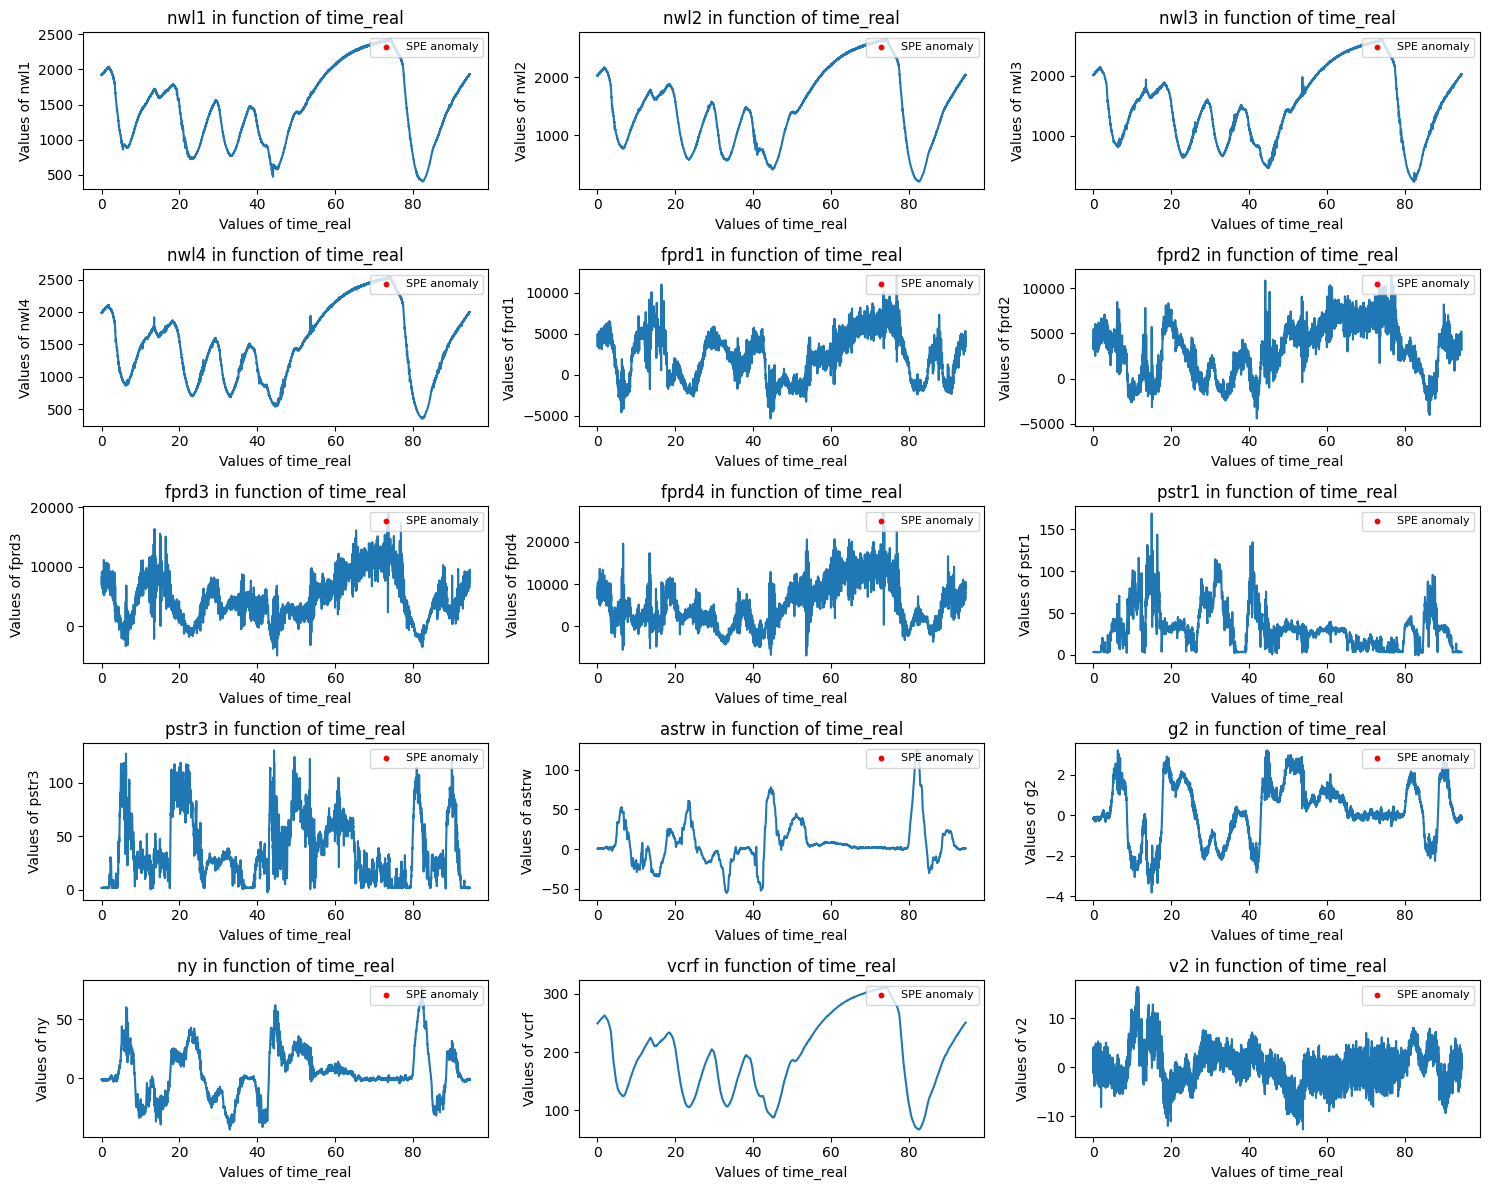

In [30]:
# Visualize anomalies

anomaly_mask = pca_anomaly_detection(df[cols], pca, scaler, seuil, d=ncp, method="SPE")
visualisation_anomalies(df, anomaly_mask, cols, method="pca")


### IF

In [31]:
# Isolation forest on PCA space
clean = clf_if.predict_anomalies(pd.DataFrame(respca))
clean

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,anomaly_score,is_anomaly,anomaly_detected
0,2.717462,-0.094261,-1.352259,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.166706,1,0
1,2.590617,-0.035076,-1.271821,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.180477,1,0
2,2.372237,0.058461,-1.195277,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.180148,1,0
3,2.555183,-0.068438,-1.301209,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.175800,1,0
4,2.700106,-0.006776,-1.263614,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.175987,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
231802,2.573742,-0.443875,-1.397346,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.141743,1,0
231803,2.617873,-0.331951,-1.341615,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.157029,1,0
231804,2.537622,-0.072690,-1.184376,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.184099,1,0
231805,2.672229,-0.458601,-1.453127,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.133435,1,0


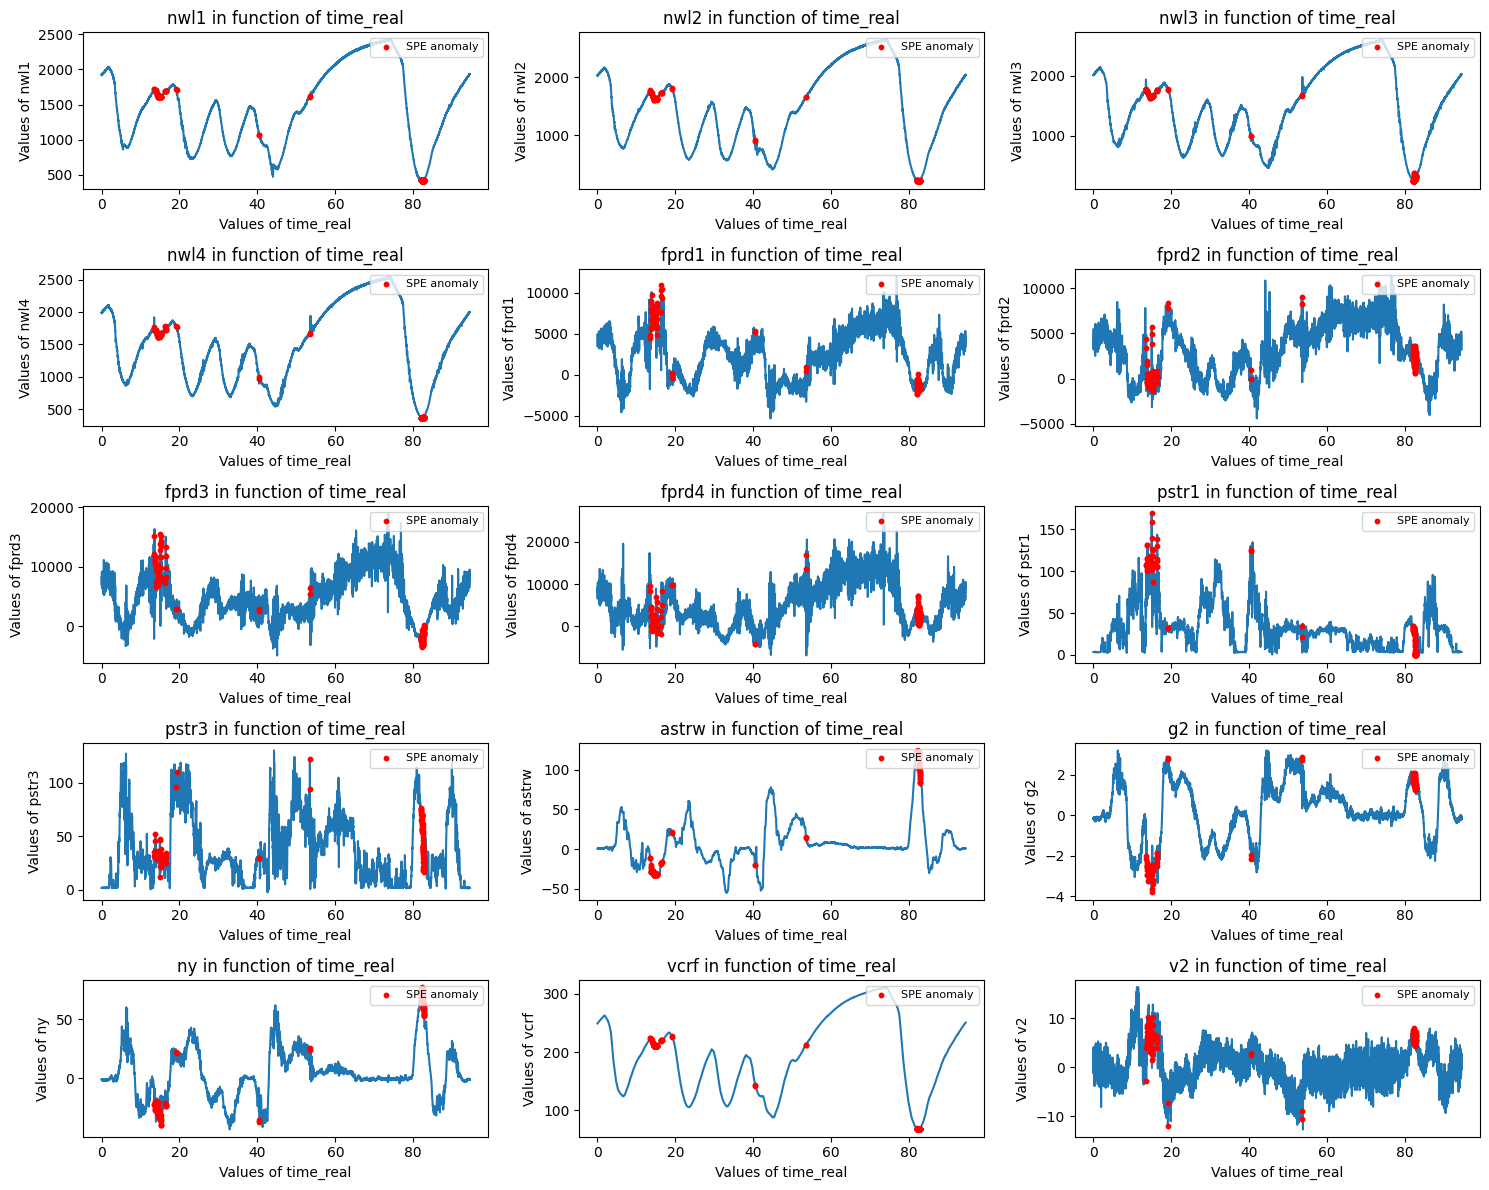

In [32]:
# Visualize anomalies
anomaly_mask = pca_anomaly_detection(df[cols], pca, scaler, seuil, d=ncp, method="IF", clf_IF=clf_if)
visualisation_anomalies(df, anomaly_mask, cols, method="pca")

## MGKPCA

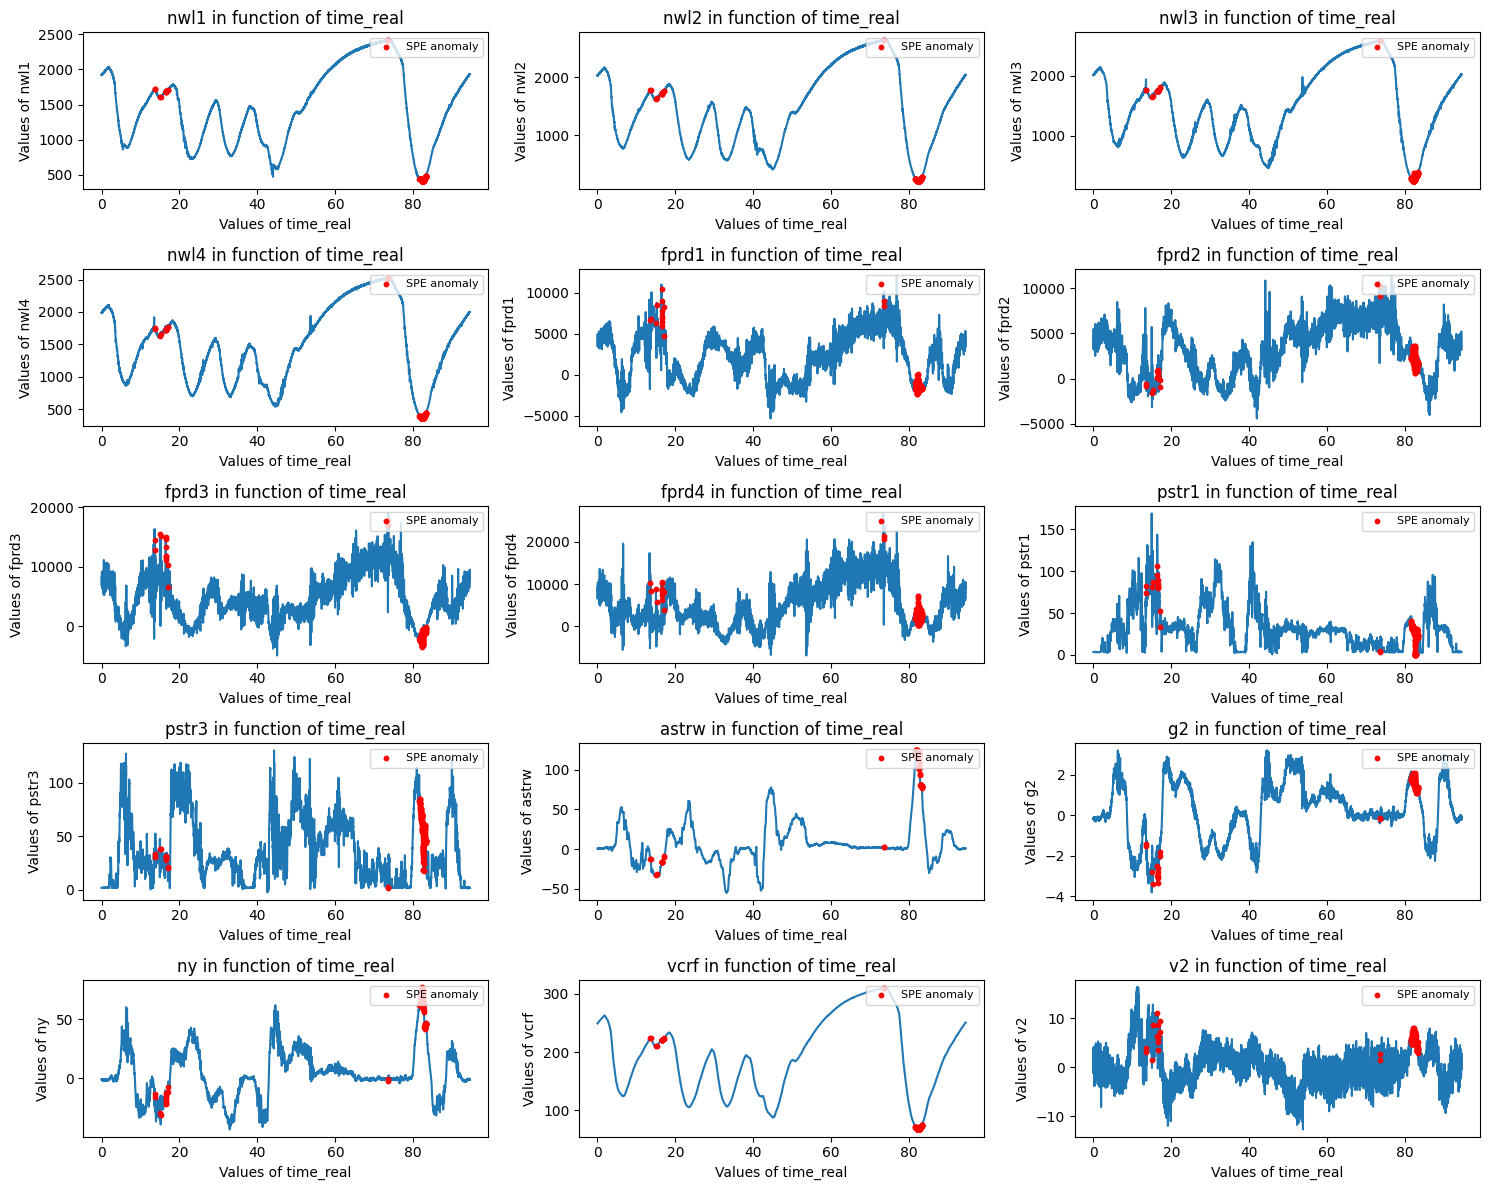

In [33]:
anomaly_mask = pca_anomaly_detection(df[cols], mgkpca, scaler, seuil, d=ncp, method="IF", clf_IF=clf_if_kpca)
visualisation_anomalies(df, anomaly_mask, cols, method="pca")

## Dynamic PCA

### SPE

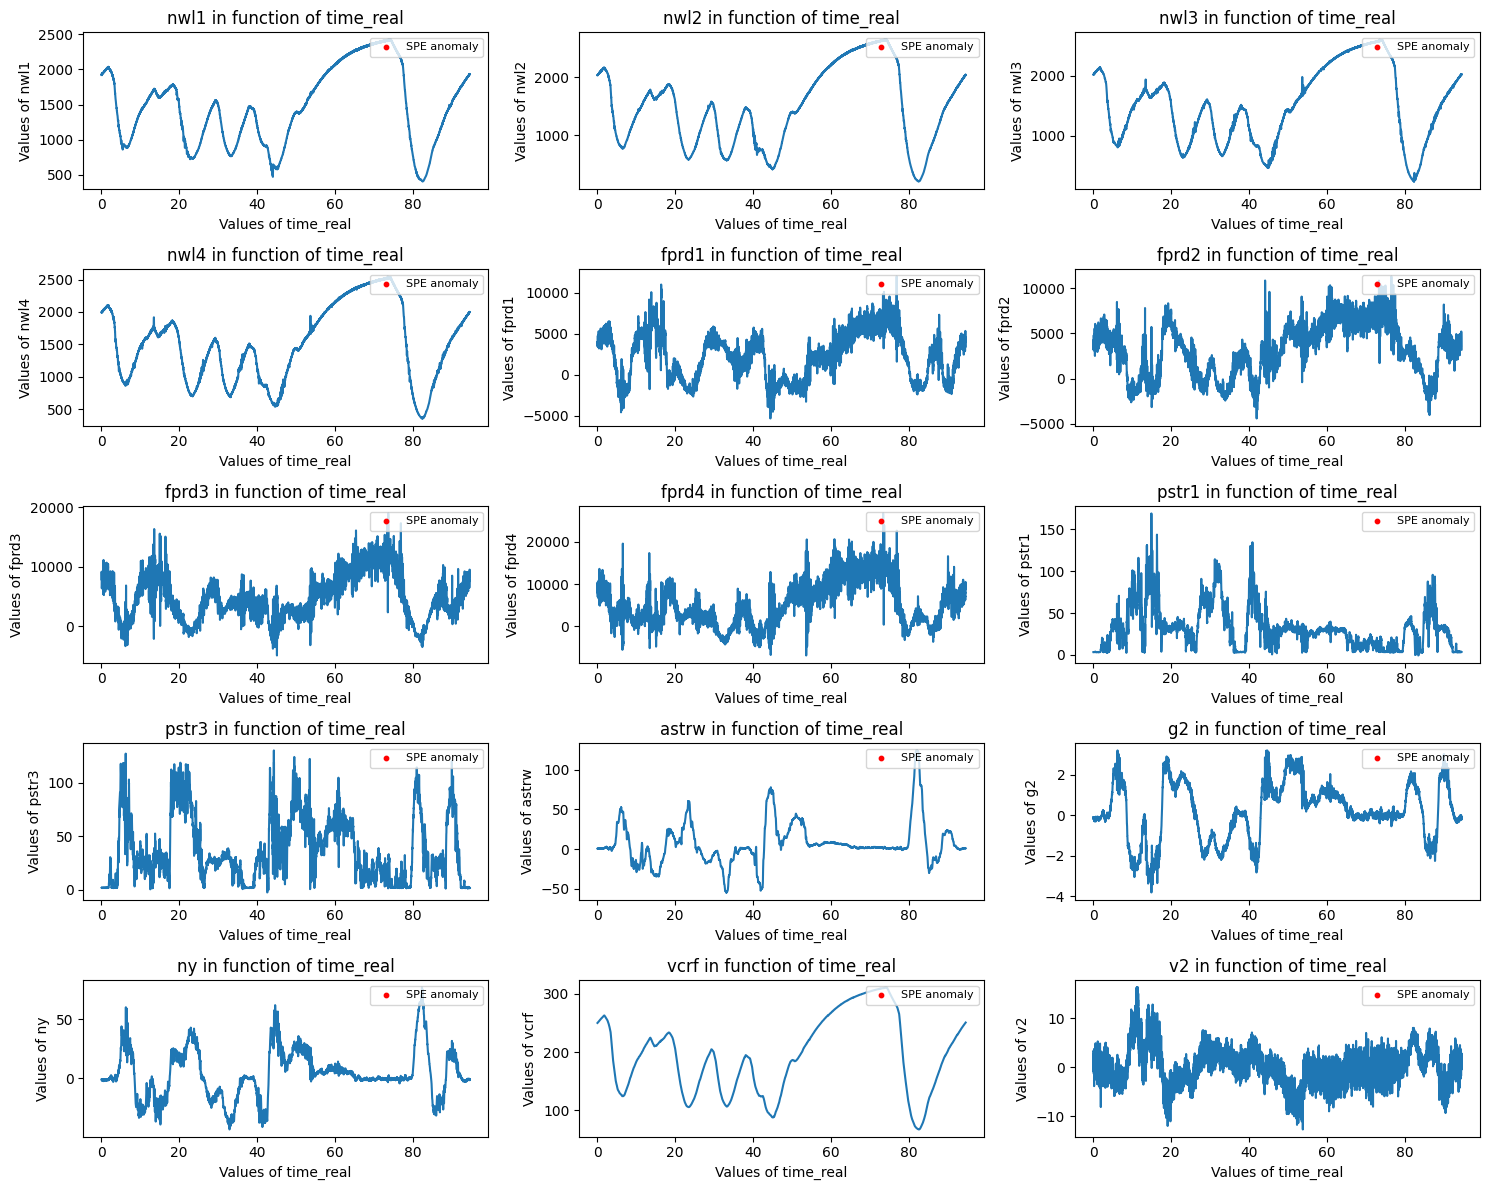

In [34]:
anomaly_mask = dpca_anomaly_detection(df[cols], dpca, scaler, seuilD, d=ncp, method="SPE")
visualisation_anomalies(df, anomaly_mask, cols, method="dpca")

### IF

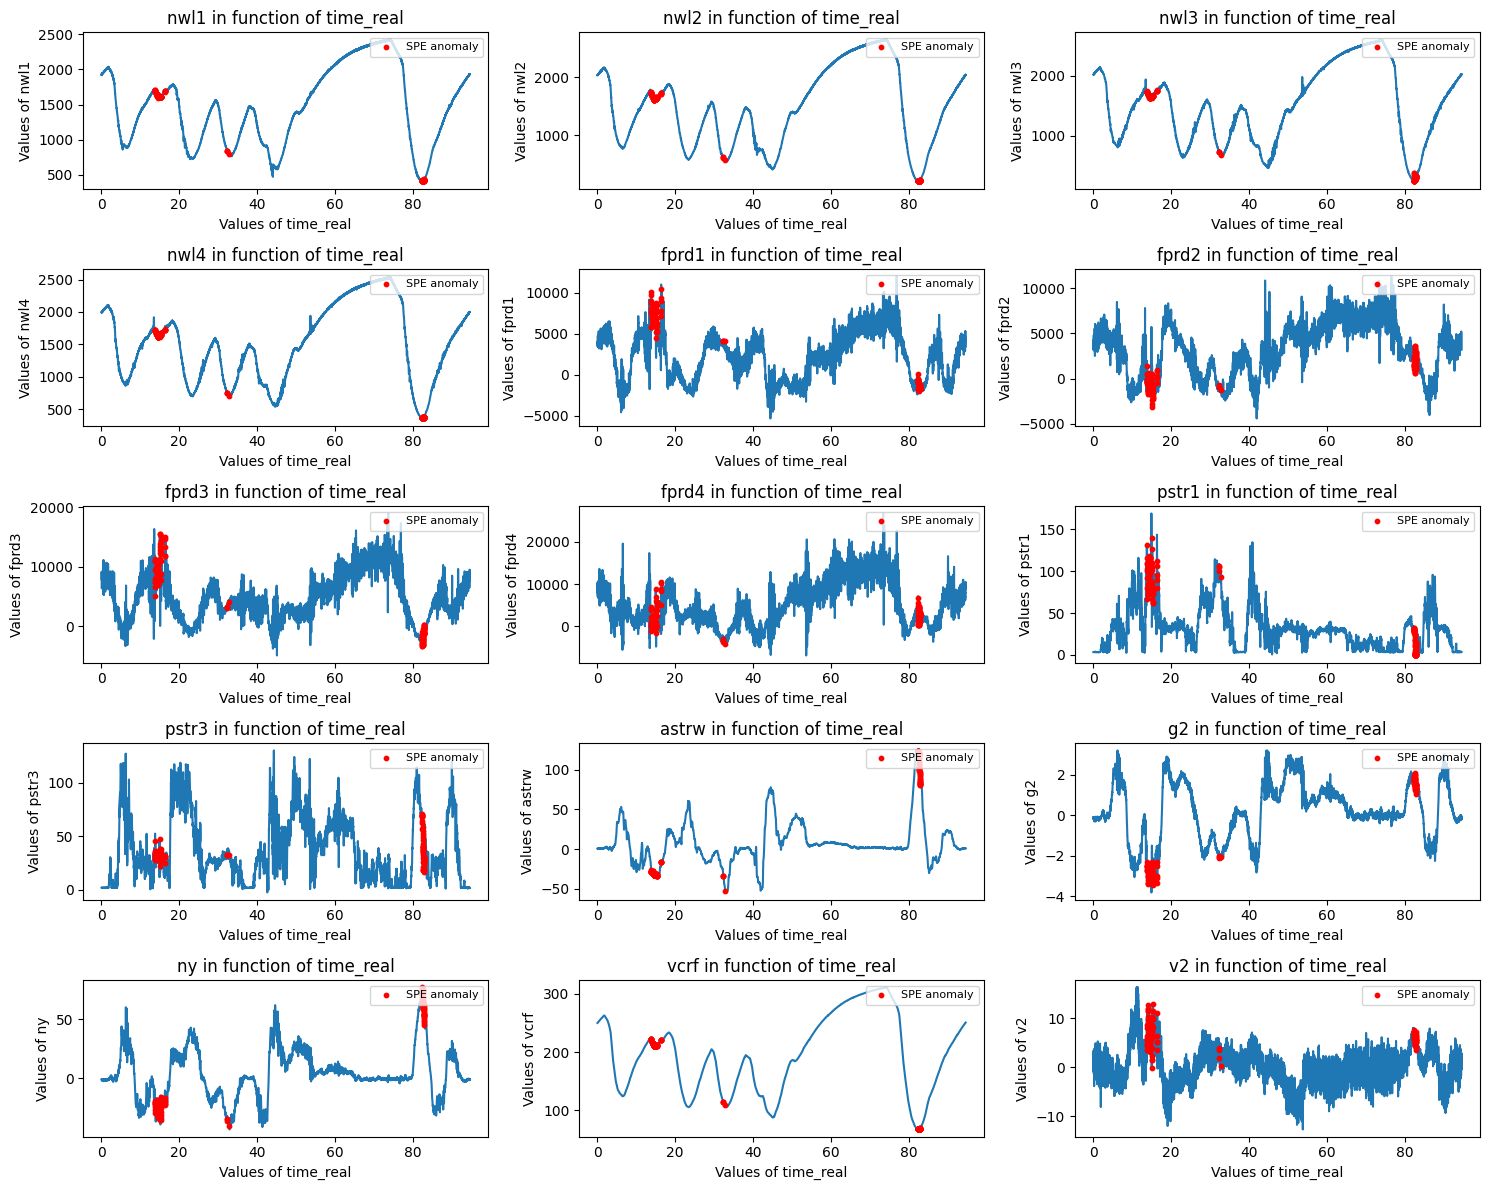

In [35]:
# Visualize anomalies
anomaly_mask_dy = dpca_anomaly_detection(df[cols], dpca, scaler, seuilD, d=ncp, method="IF", clf_IF=clf_if_dy)
visualisation_anomalies(df, anomaly_mask_dy, cols, method="dpca")

## Full test

In [36]:
results = []

for session_name in session_test:
    
    df_test = data_dict[session_name].copy()
    df_test = preprocessing.clean_dataframe(df_test)
    
    X = df_test[cols]
    n = len(X)
    
    # --- PCA ---
    mask_pca_spe = pca_anomaly_detection(X, pca, scaler, seuil, method="SPE", d=ncp)
    mask_pca_if  = pca_anomaly_detection(X, pca, scaler, method="IF", clf_IF=clf_if, d=ncp)
    
    # --- DPCA ---
    mask_dpca_spe = dpca_anomaly_detection(X, dpca, scaler, seuilD, method="SPE", d=ncp)
    mask_dpca_if  = dpca_anomaly_detection(X, dpca, scaler, method="IF", clf_IF=clf_if_dy, d=ncp)

    # --- global IF ---
    mask_global_if = clf_glob.predict_anomalies(X)["anomaly_detected"]==1

    # --- MGKPCA IF ---
    mask_mgkpca_if = pca_anomaly_detection(X, mgkpca, scaler, method="IF", clf_IF=clf_if_kpca, d=ncp)
    # --- compute percentages ---
    res = {
        "session": os.path.basename(session_name),
        "pca_spe_%": mask_pca_spe.sum() / n * 100,
        "pca_if_%":  mask_pca_if.sum() / n * 100,
        "dpca_spe_%": mask_dpca_spe.sum() / n * 100,
        "dpca_if_%":  mask_dpca_if.sum() / n * 100,
        "global_if_%": mask_global_if.sum() / n * 100,
        "mgkpca_if_%": mask_mgkpca_if.sum() / n * 100,
    }
    
    results.append(res)

# convert to DataFrame
df_results = pd.DataFrame(results)

In [37]:
df_results

,session,pca_spe_%,pca_if_%,dpca_spe_%,dpca_if_%,global_if_%,mgkpca_if_%
0,T24S12-04_E-AL3143.csv,0.0,1.620227,0.0,1.692466,1.671827,0.319917
1,T24S12-04_E-AL3052.csv,0.0,1.251314,0.0,0.694006,0.567823,1.135647
2,T24S12-04_E-AL2889.csv,0.0,0.756028,0.0,0.592562,0.929710,0.827544
3,T24S12-04_E-AL3358.csv,0.0,1.057082,0.0,1.532770,0.898520,1.331924
4,T24S12-04_E-AL3397.csv,0.0,1.226216,0.0,1.458774,1.205074,1.035941
5,T24S12-04_E-AL3319.csv,0.0,1.322751,0.0,1.481481,0.910053,1.301587


In [38]:
visualisation_plot(preprocessing.clean_dataframe(data_dict[session_test[7]]), cols)

IndexError: list index out of range

In [ ]:
# df_test = data_dict[session_test[7]].copy()
# df_test = preprocessing.clean_dataframe(df_test)
# mask_pca_anomaly = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, d=ncp, method="SPE")
# mask_pca_if = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, d=ncp, method="IF", clf_IF=clf_if)
# mask_dpca_anomaly = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, d=ncp, method="SPE")
# mask_dpca_if = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, d=ncp, method="IF", clf_IF=clf_if_dy)

In [ ]:
# visualisation_anomalies(df_test, mask_dpca_if, cols, method="dpca")

## Remark
- The DPCA detects more anomalies than the PCA
- SPE detects more anomalies than iForest in both latent space and original space for clean test sessions.

# Test on anomalous sessions

In [39]:
session_anomaly_test = create_session_anomaly(data_dict, session_anomaly)
len(session_anomaly_test)

10

In [40]:
df_test = data_dict[session_anomaly_test[8]].copy()
df_test = preprocessing.clean_dataframe(df_test)
mask_pca_anomaly = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="SPE")
mask_pca_if = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="IF", clf_IF=clf_if)
mask_dpca_anomaly = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="SPE")
mask_dpca_if = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="IF", clf_IF=clf_if_dy)


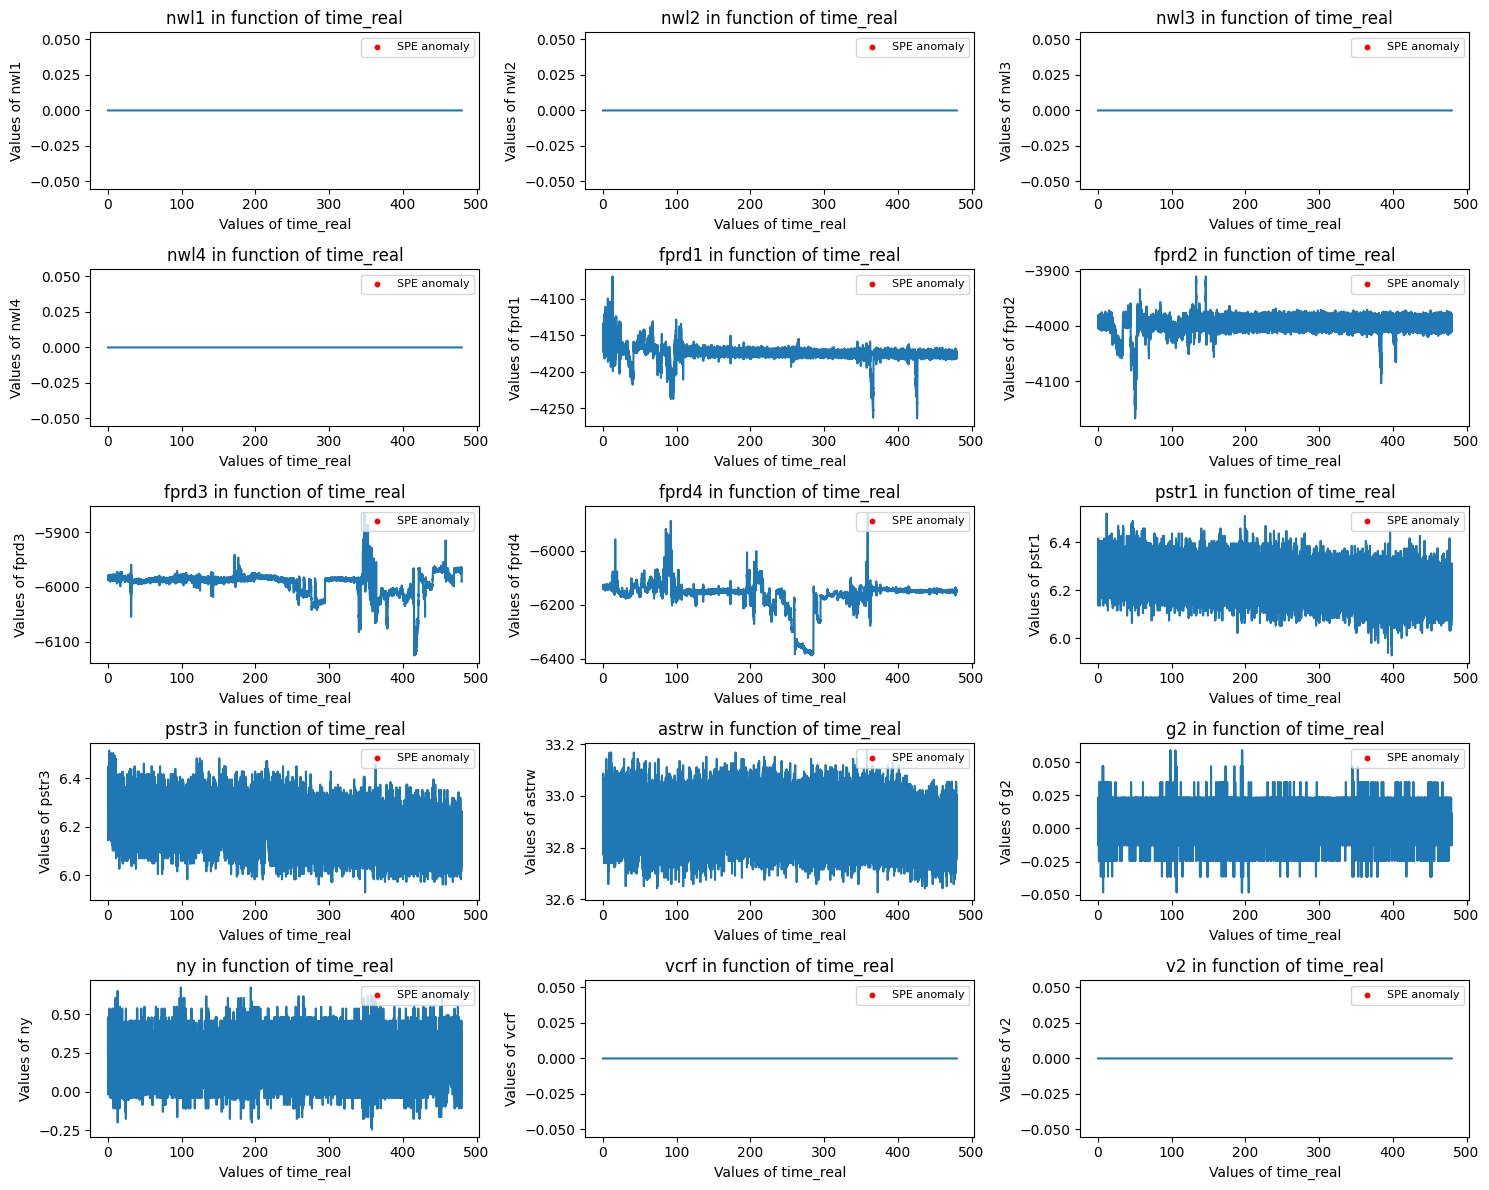

In [41]:
visualisation_anomalies(df_test, mask_pca_anomaly, cols)

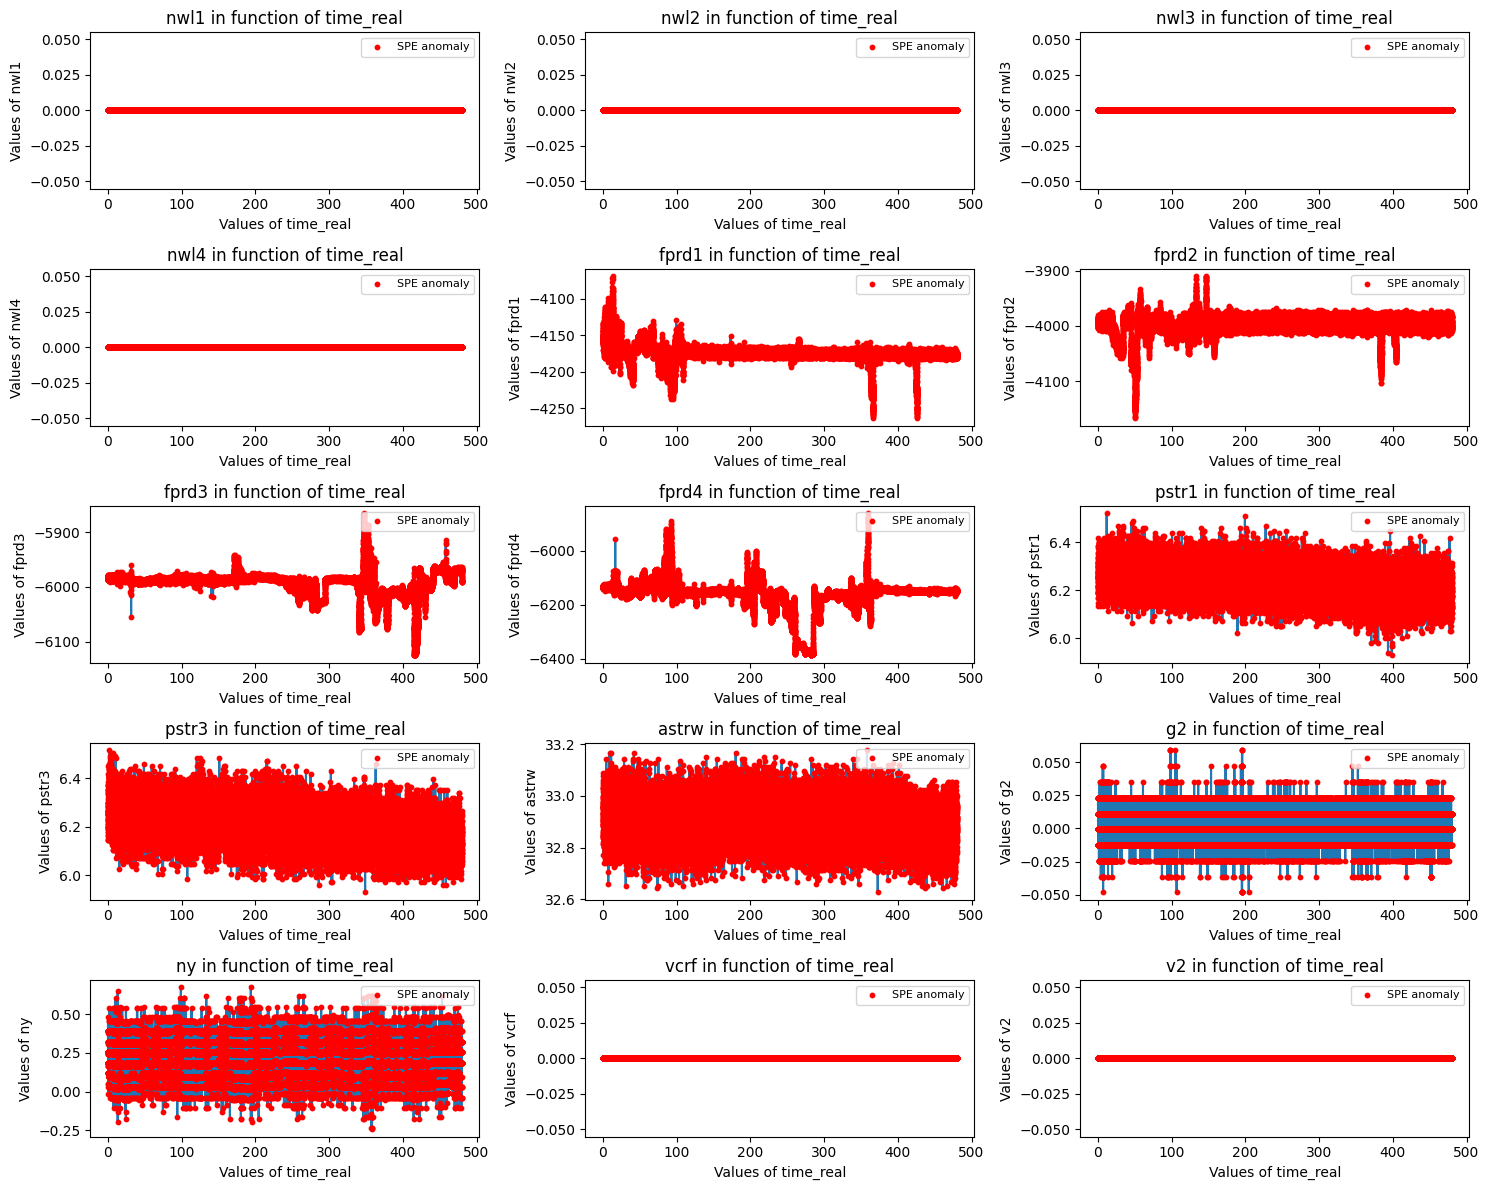

In [42]:
visualisation_anomalies(df_test, mask_pca_if, cols)

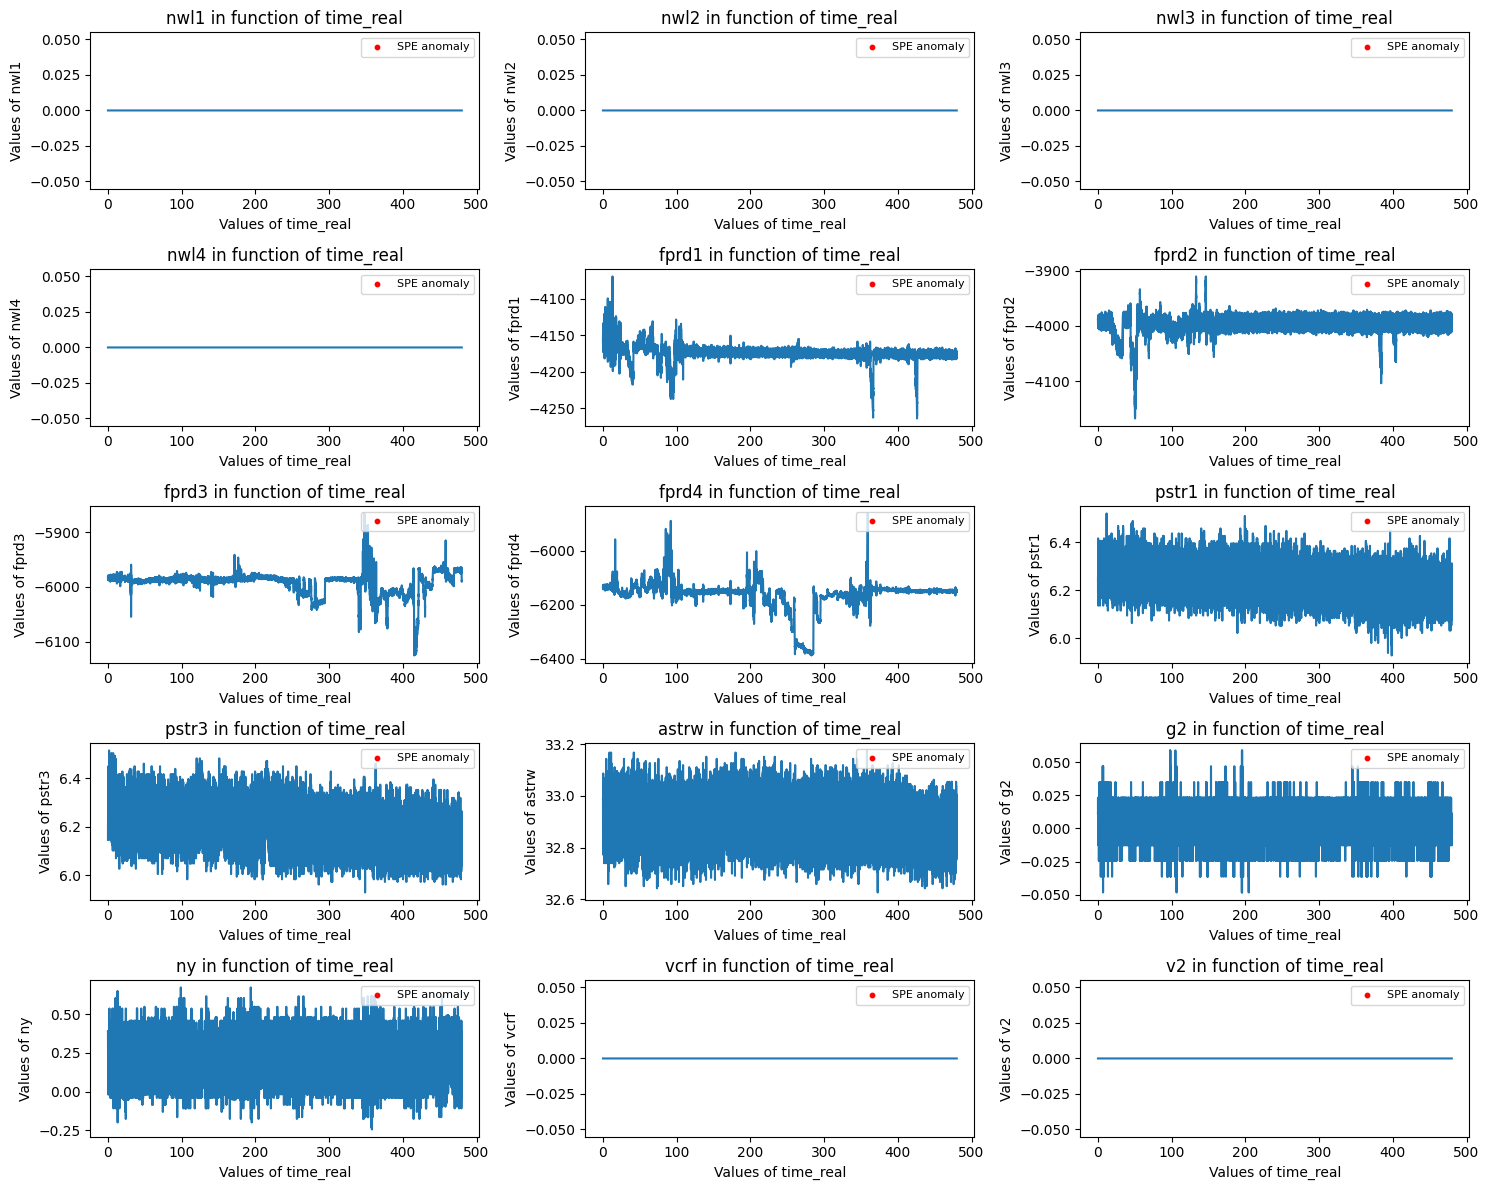

In [43]:
visualisation_anomalies(df_test, mask_dpca_anomaly, cols, method="dpca")

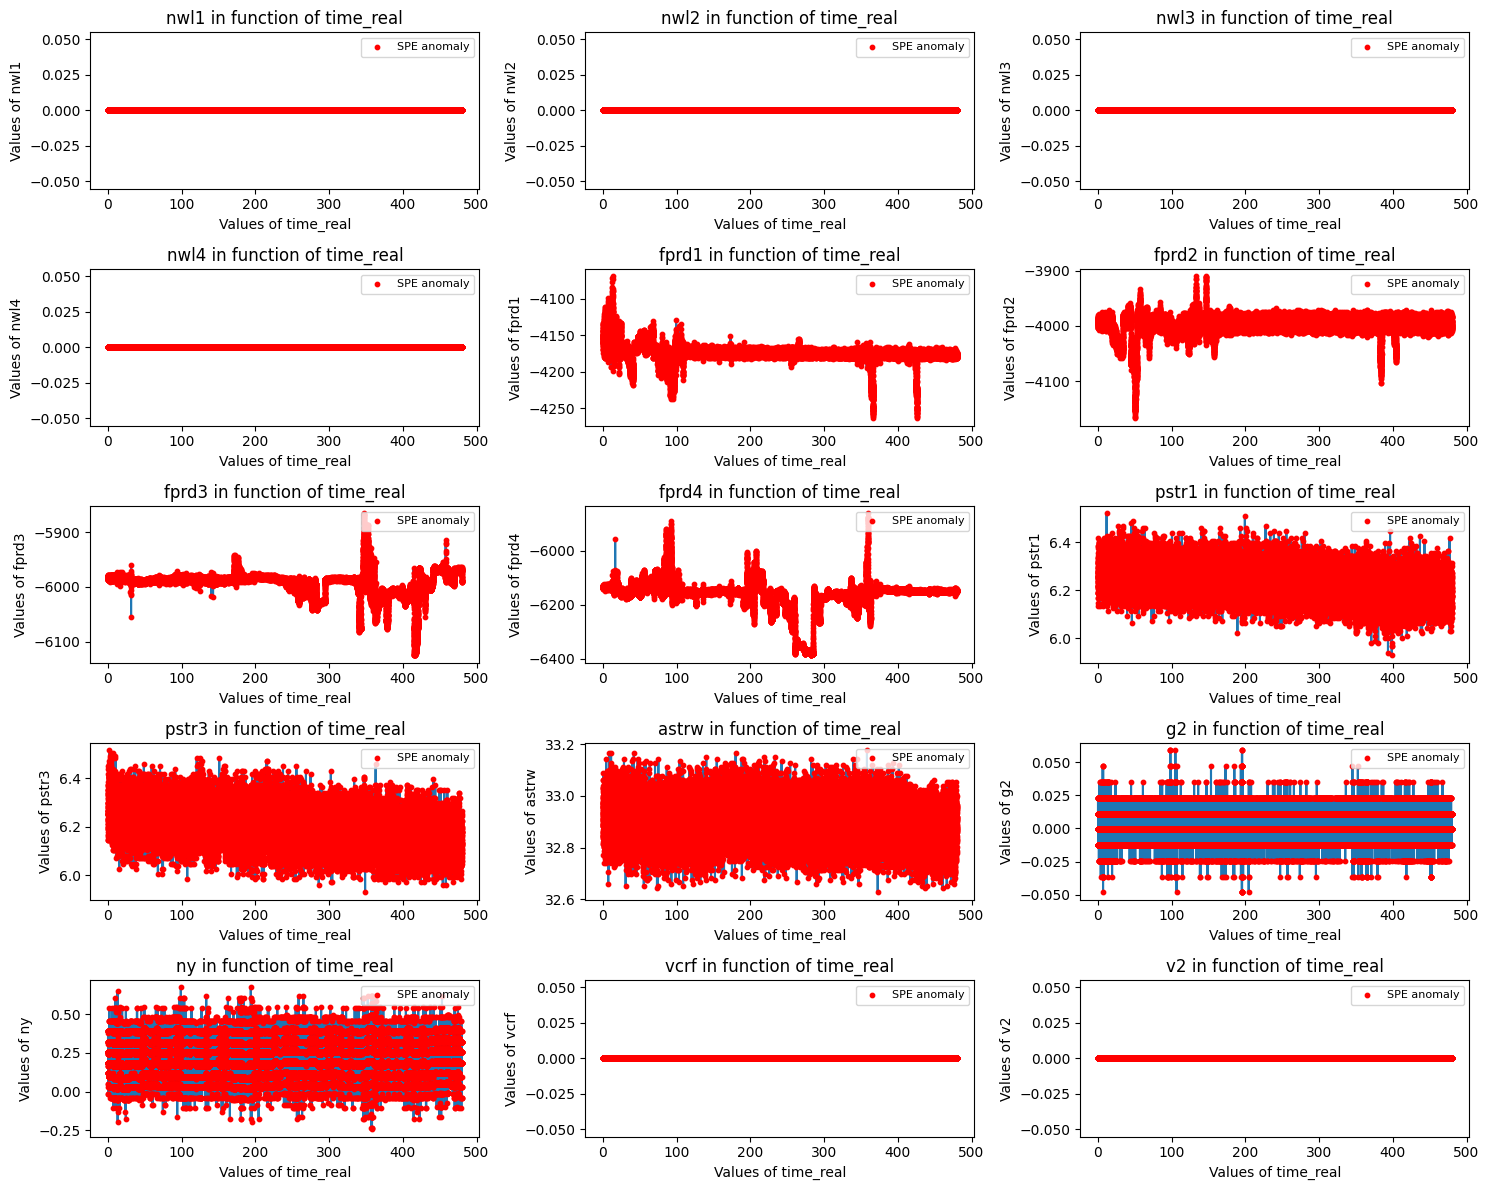

In [44]:
visualisation_anomalies(df_test, mask_dpca_if, cols, method="dpca")

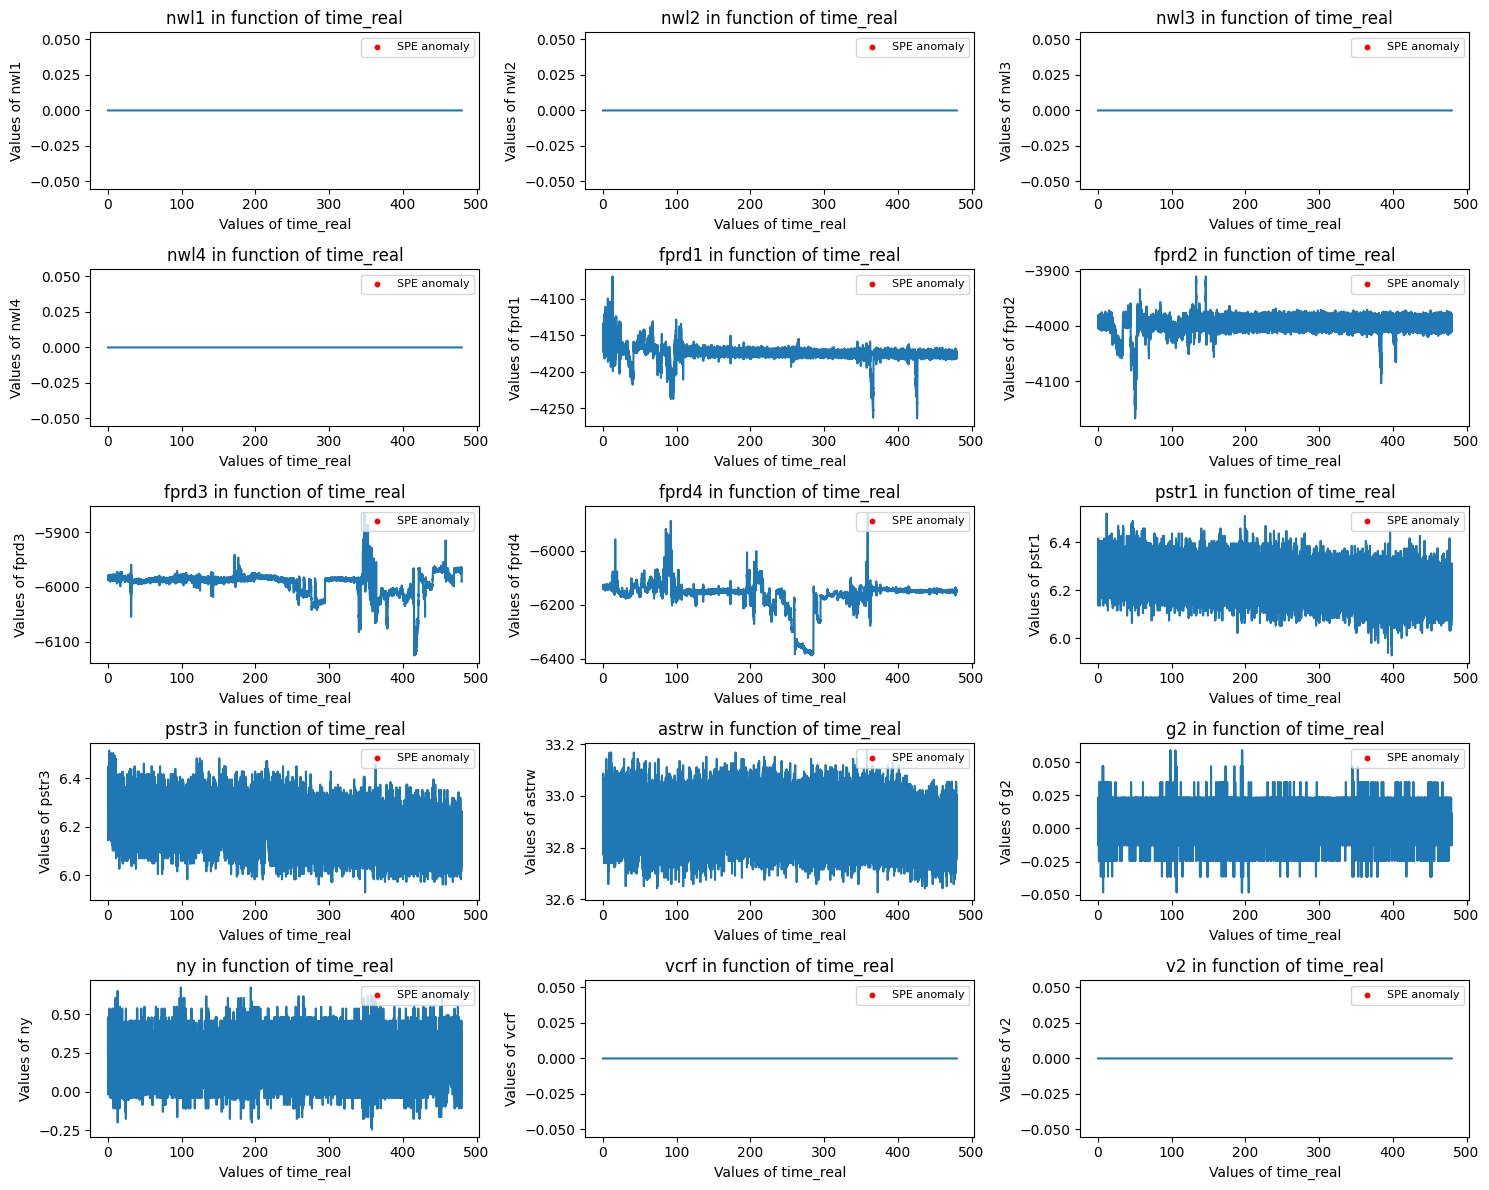

In [45]:
mask_mgkpca_if = pca_anomaly_detection(df_test[cols], mgkpca, scaler, d=ncp, method="IF", clf_IF=clf_if_kpca)
visualisation_anomalies(df_test, mask_mgkpca_if, cols)

## Full test

In [46]:
results = []

for session_name in session_anomaly_test:
    
    df_test = data_dict[session_name].copy()
    df_test = preprocessing.clean_dataframe(df_test)
    
    X = df_test[cols]
    n = len(X)
    
    # --- PCA ---
    mask_pca_spe = pca_anomaly_detection(X, pca, scaler, seuil, method="SPE", d=ncp)
    mask_pca_if  = pca_anomaly_detection(X, pca, scaler, method="IF", clf_IF=clf_if, d=ncp)
    
    # --- DPCA ---
    mask_dpca_spe = dpca_anomaly_detection(X, dpca, scaler, seuilD, method="SPE", d=ncp)
    mask_dpca_if  = dpca_anomaly_detection(X, dpca, scaler, method="IF", clf_IF=clf_if_dy, d=ncp)

    # --- global IF ---
    mask_global_if = clf_glob.predict_anomalies(X)["anomaly_detected"]==1

    # --- MGKPCA IF ---
    mask_mgkpca_if = pca_anomaly_detection(X, mgkpca, scaler, method="IF", clf_IF=clf_if_kpca, d=ncp)
    # --- compute percentages ---
    res = {
        "session": os.path.basename(session_name),
        "pca_spe_%": mask_pca_spe.sum() / n * 100,
        "pca_if_%":  mask_pca_if.sum() / n * 100,
        "dpca_spe_%": mask_dpca_spe.sum() / n * 100,
        "dpca_if_%":  mask_dpca_if.sum() / n * 100,
        "global_if_%": mask_global_if.sum() / n * 100,
        "mgkpca_if_%": mask_mgkpca_if.sum() / n * 100,
    }
    
    results.append(res)

# convert to DataFrame
df_results = pd.DataFrame(results)

In [47]:
df_results

,session,pca_spe_%,pca_if_%,dpca_spe_%,dpca_if_%,global_if_%,mgkpca_if_%
0,T24S12-04_E-AL2706.csv,0.0,100.000000,0.0,99.983333,100.000000,0.000000
1,T24S12-04_E-AL2725.csv,0.0,90.200708,0.0,89.846517,90.495868,0.000000
2,T24S12-04_E-AL2761.csv,0.0,100.000000,0.0,99.953986,100.000000,0.000000
3,T24S12-04_E-AL2780.csv,0.0,1.054280,0.0,1.252610,1.680585,1.043841
4,T24S12-04_E-AL2819.csv,0.0,100.000000,0.0,99.983333,100.000000,0.000000
5,T24S12-04_E-AL2948.csv,0.0,100.000000,0.0,95.294118,0.000000,0.000000
6,T24S12-04_E-AL3089.csv,0.0,73.822917,0.0,73.922917,48.375000,0.227083
7,T24S12-04_E-AL3155.csv,0.0,100.000000,0.0,99.983333,100.000000,0.000000
8,T24S12-04_E-AL3597.csv,0.0,100.000000,0.0,99.983333,100.000000,0.000000
9,T24S12-04_E-AL3674.csv,0.0,79.347225,0.0,79.332473,67.765075,0.182556


## Analyze one session

We will concentrate on session 2780 where iForest detects few anomalies, while the SPE detects alot.

In [75]:
session_anomaly_test[3]

'd:\\GMM 4\\Reading seminar\\data_download\\gdrive_tar_data\\extracted\\fetching_data_examples_for_PIR-ARAG24\\T24S12-04_E-AL2780.csv'

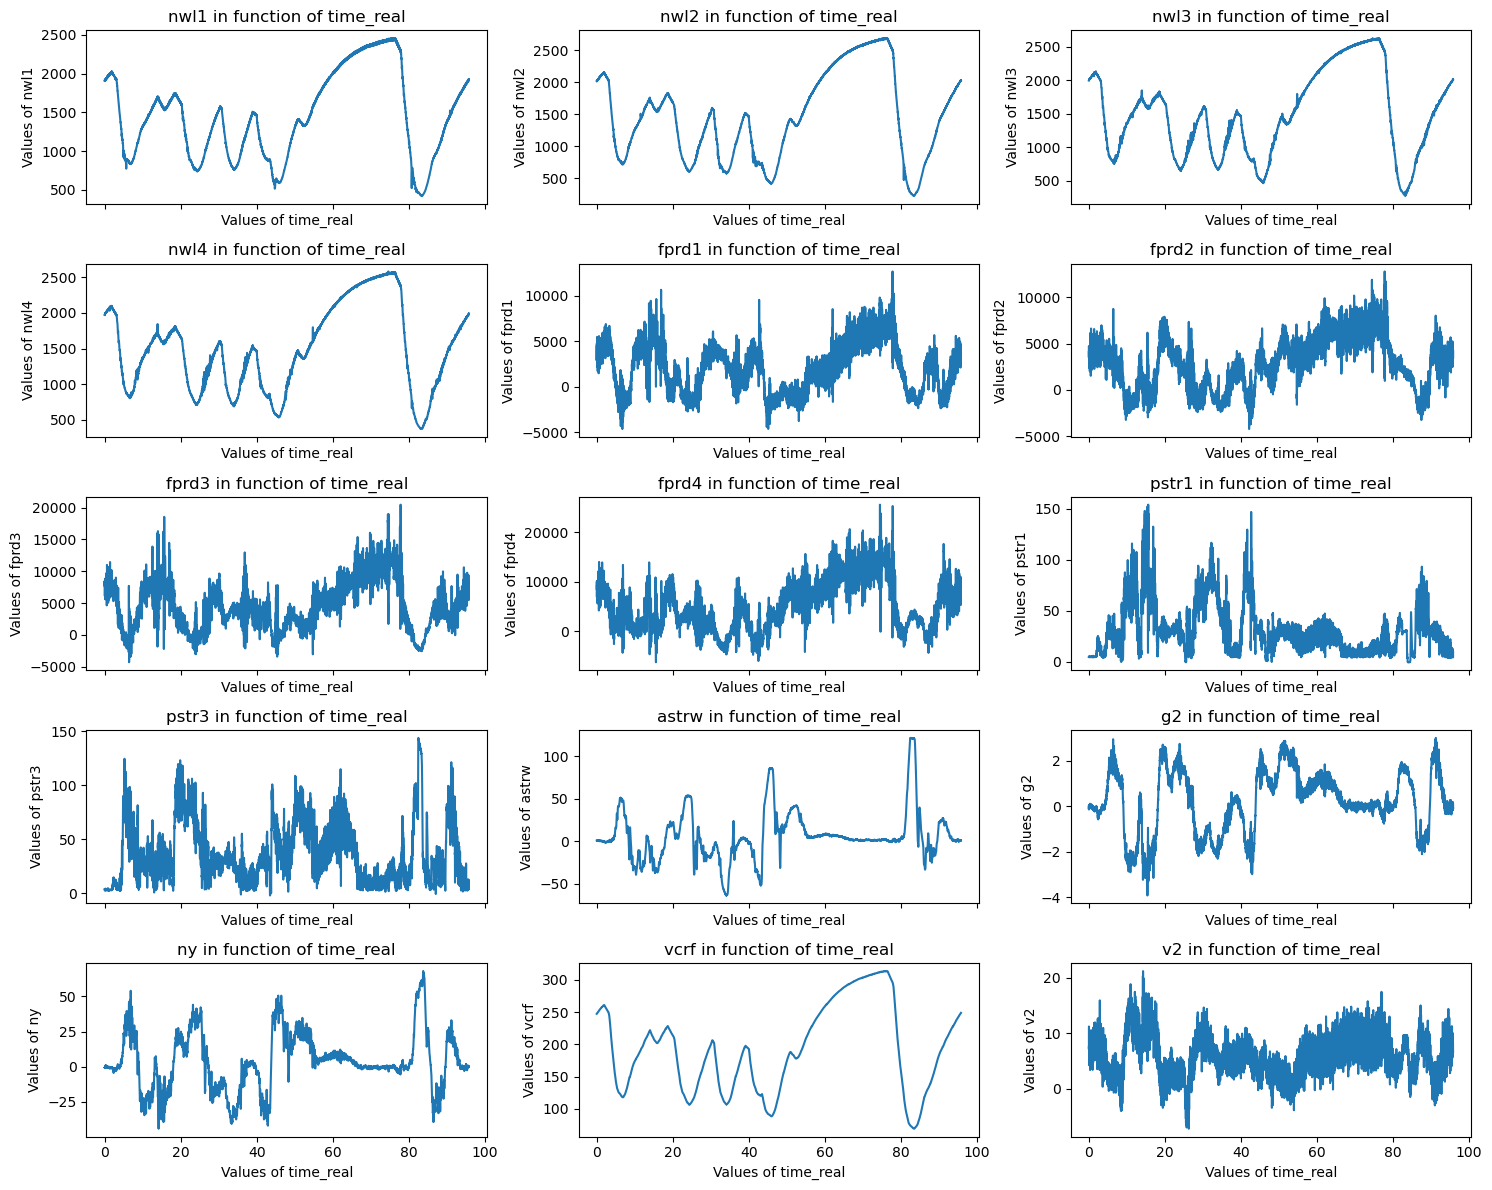

In [76]:
df_test = data_dict[session_anomaly_test[3]].copy()
df_test = preprocessing.clean_dataframe(df_test)
visualisation_plot(df_test, cols)

In [77]:
# --- PCA ---
mask_pca_spe = pca_anomaly_detection(df_test[cols], pca, scaler, seuil, method="SPE", d=ncp)
mask_pca_if  = pca_anomaly_detection(df_test[cols], pca, scaler, method="IF", clf_IF=clf_if, d=ncp)
    
    # --- DPCA ---
mask_dpca_spe = dpca_anomaly_detection(df_test[cols], dpca, scaler, seuilD, method="SPE", d=ncp)
mask_dpca_if  = dpca_anomaly_detection(df_test[cols], dpca, scaler, method="IF", clf_IF=clf_if_dy, d=ncp)

    # --- global IF ---
mask_global_if = clf_glob.predict_anomalies(df_test[cols])["anomaly_detected"]==1

    # --- MGKPCA IF ---
mask_mgkpca_if = pca_anomaly_detection(df_test[cols], mgkpca, scaler, method="IF", clf_IF=clf_if_kpca, d=ncp)

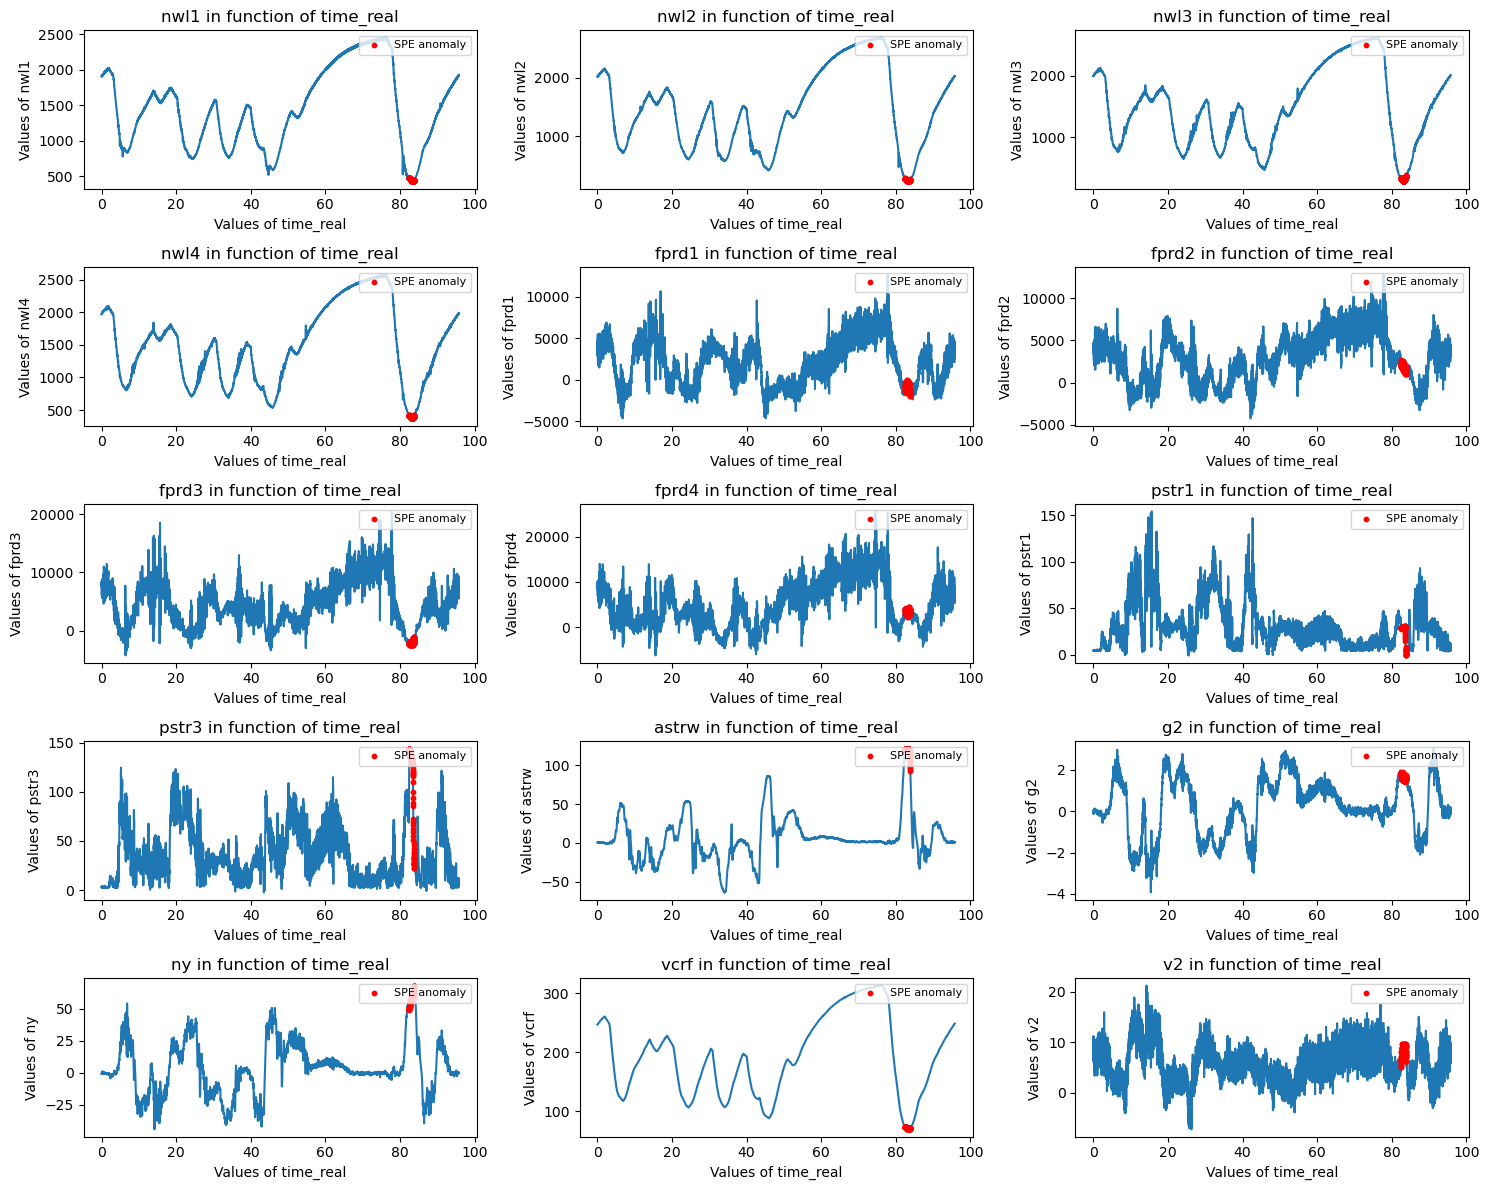

In [78]:
visualisation_anomalies(df_test, mask_mgkpca_if, cols)

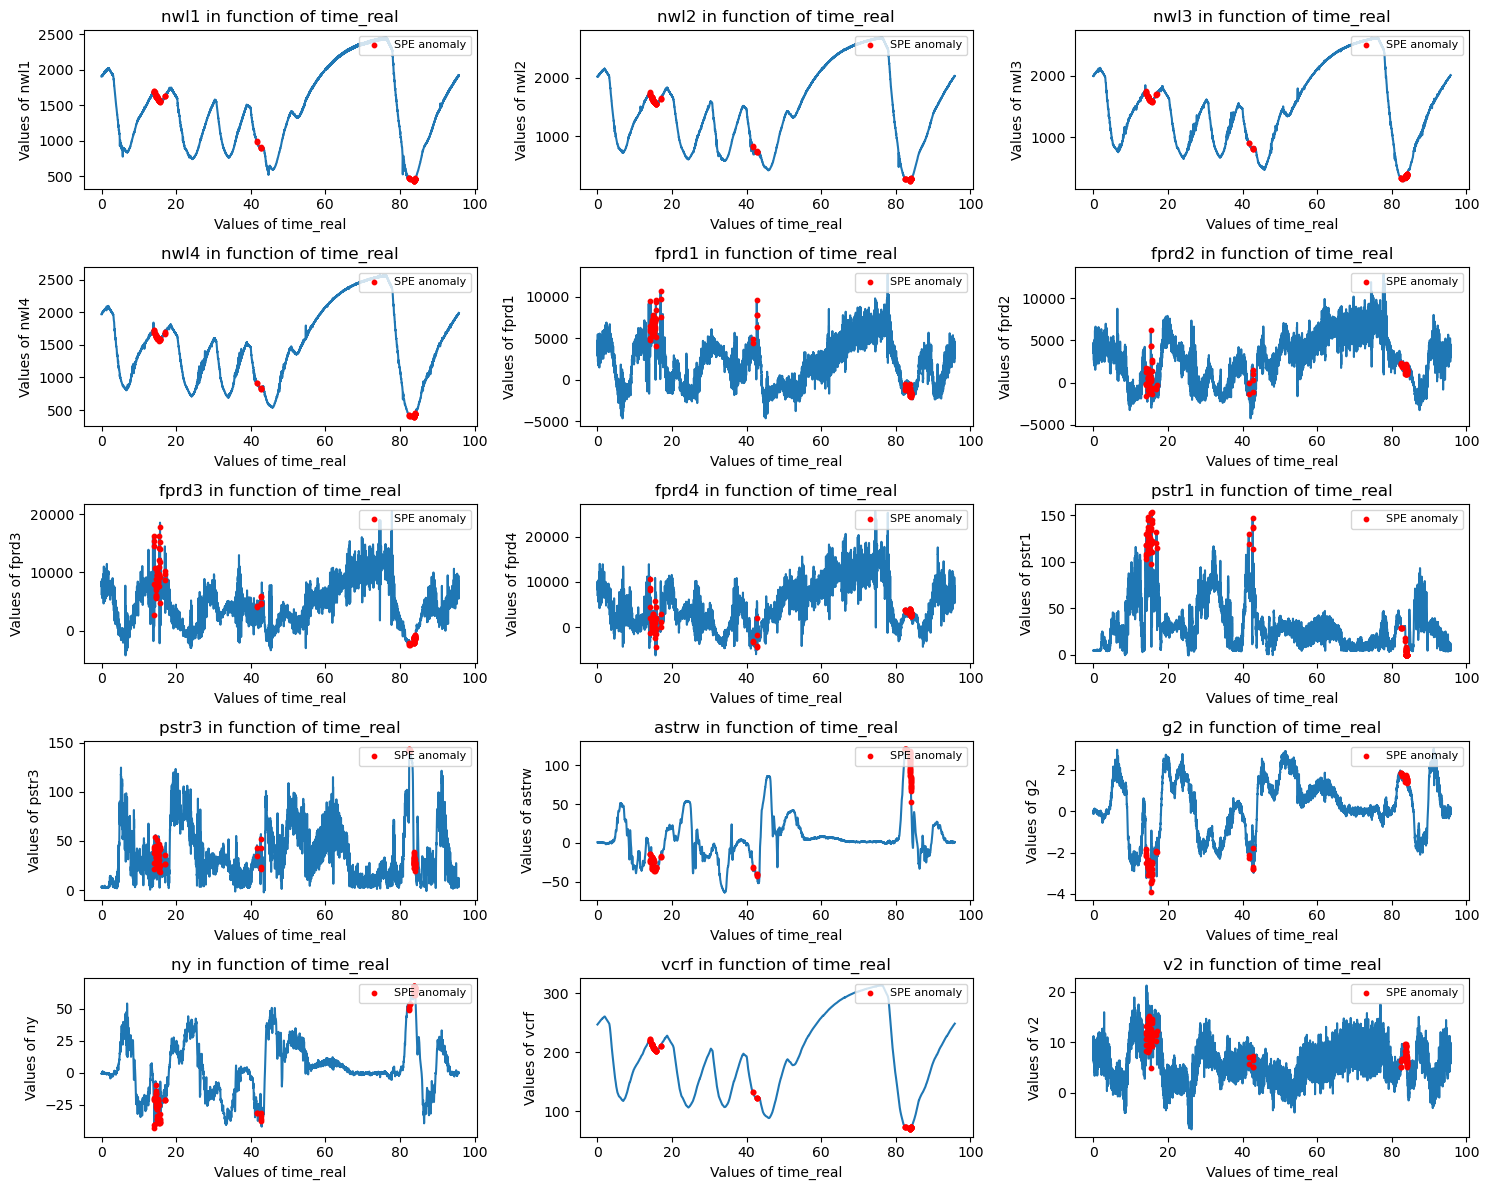

In [80]:
visualisation_anomalies(df_test, mask_pca_if, cols)

## Conclusion
- SPE can't detect anomalies in many anomalous sessions
- For session 2780, the sensor v2 is not centered in 0, but non of the methods can detect.
- In general the iForest in latent space is more stable and better than iForest alone or SPE. 


## Test on other session (second circuit)

In [3]:
%load_ext autoreload
%autoreload 2

config_dir = "../config"
if config_dir not in sys.path:
    sys.path.insert(0, config_dir)

from config import add_to_path, root_dir,google_folder_id, google_folder_id2, download_dir
add_to_path(join(root_dir, 'src'))
import utils.visualization as visualisation
import utils.preprocessing as preprocessing
from data_loader import load_data

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Already in sys: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\Projet-recheche-INSA-anomaly-detection-librairy-1\src


In [ ]:
data_dict2, extracted_dir = load_data(
    file_id=google_folder_id2,
    work_dir=join(download_dir, "gdrive_tar_data"),
    tar_name="data2.tar",
    pattern="*.csv",
)
print(len(data_dict2), "CSV files loaded")
first_key = next(iter(data_dict2))
print("Example file:", first_key)
print(data_dict2[first_key].head())

list_keys2 = list(data_dict2.keys())
list_session2 = []
for s in list_keys2:
    df = data_dict2[s].copy()
    if preprocessing.clean_dataframe(df).shape[0] != 0:
        list_session2.append(s)

Extracted data found at: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
Loading CAST data from: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24
64 CSV files loaded
Example file: c:\Users\fauli\OneDrive\Bureau\INSA\quatrième_année\deuxieme_semestre\projet recheche\library\data_download\gdrive_tar_data\extracted\fetching_data_examples_for_PIR-CAST24\T24S15-04_E-AL10009.csv
                  datetime     nwl1     nwl2     nwl3     nwl4    fprd1  \
0  2024-05-27T06:27:25.884  1758.07  1819.07  1818.91  1804.18  1716.18   
1  2024-05-27T06:27:25.894  1756.17  1824.98  1820.00  1810.42  1689.52   
2  2024-05-27T06:27:25.904  1767.57  1822.61  1815.63  1798.98  1657.06   
3  2024-05-27T06:27:25.914  1765.67  1822.61  1816.72  1801.06  1800.80   
4 

In [5]:
import joblib
clean_session2 = joblib.load('models/sessions_saines_circuit2.joblib')
len(clean_session2)

36

In [6]:
type(clean_session2)

list

In [49]:
data_dict2[clean_session2[7]]

,datetime,nwl1,nwl2,nwl3,nwl4,fprd1,fprd2,fprd3,fprd4,pstr1,pstr3,astrw,g2,ny,vcrf,v2
0,2024-04-30T06:11:54.294,1754.93,1824.86,1822.26,1807.27,2027.28,1760.08,4222.02,4880.73,2.85900,1.71289,-1.45578,0.021699,0.745269,229.007,-0.693166
1,2024-04-30T06:11:54.304,1755.88,1824.86,1823.35,1814.54,2682.20,2580.74,5007.46,4720.55,2.83819,1.74538,-1.33455,0.128616,0.813247,229.184,-0.253310
2,2024-04-30T06:11:54.314,1764.42,1828.40,1827.72,1806.23,2801.59,3090.77,5620.36,3894.46,2.71334,1.84287,-1.23756,0.211773,0.892556,229.273,0.123710
3,2024-04-30T06:11:54.324,1762.52,1831.94,1825.54,1810.39,2492.10,2598.14,4894.08,4450.52,2.68212,1.97286,-1.26181,0.140495,1.459040,229.450,-4.431940
4,2024-04-30T06:11:54.334,1759.67,1827.22,1823.35,1812.47,3070.52,2220.25,5140.55,5100.42,2.79657,1.84287,-1.26989,0.211773,1.232450,229.627,1.411860
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10390,2024-04-30T06:13:38.194,1758.72,1827.22,1821.17,1810.39,2915.19,3397.94,5830.69,5523.77,3.54569,2.29783,-1.86798,0.009819,-0.614304,229.273,-1.918480
10391,2024-04-30T06:13:38.204,1764.42,1826.04,1825.54,1803.11,2923.30,2209.83,5055.10,4070.66,2.91102,2.05952,-1.92456,0.069218,0.020164,229.361,3.077030
10392,2024-04-30T06:13:38.214,1763.47,1827.22,1821.17,1807.27,2456.16,1673.14,5216.14,4528.33,2.86940,2.04869,-1.88415,0.116736,-0.115794,229.538,-2.389750
10393,2024-04-30T06:13:38.224,1757.77,1829.58,1826.63,1812.47,2018.01,2289.80,6579.98,6905.94,3.02547,1.86454,-1.74675,0.021699,0.937875,229.627,2.228730


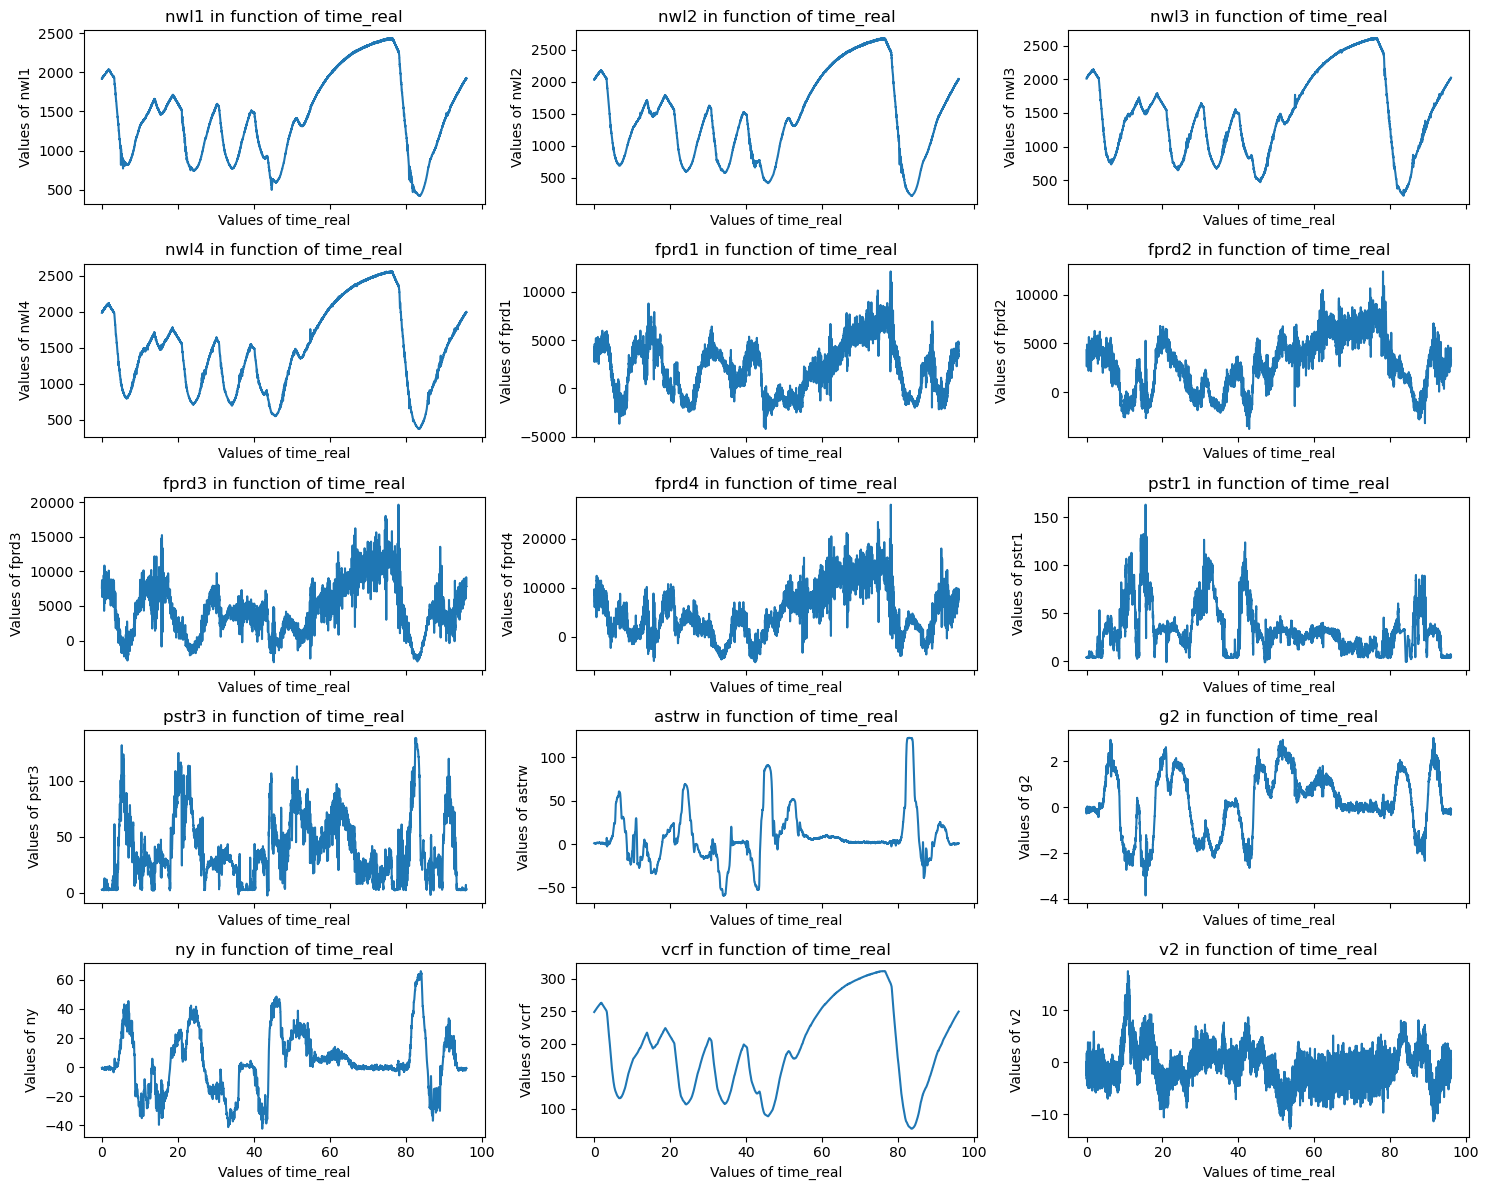

In [59]:

df = data_dict[list_session[5]].copy()
df = preprocessing.clean_dataframe(df)
cols = df.columns[1:-1]
visualisation_plot(df, cols)

In [38]:
results_clean2 = []

for session_name in clean_session2:
    
    df_test = data_dict2[session_name].copy()
    df_test = preprocessing.clean_dataframe(df_test)
    
    X = df_test[cols]
    n = len(X)
    
    # --- PCA ---
    mask_pca_if  = pca_anomaly_detection(X, pca, scaler, method="IF", clf_IF=clf_if, d=ncp)
    

    # --- global IF ---
    mask_global_if = clf_glob.predict_anomalies(X)["anomaly_detected"]==1
    # --- compute percentages ---
    res = {
        "session": os.path.basename(session_name),
        "pca_if_%":  mask_pca_if.sum() / n * 100,
        "global_if_%": mask_global_if.sum() / n * 100,
    }
    
    results_clean2.append(res)

# convert to DataFrame
df_results_clean2 = pd.DataFrame(results_clean2)

In [39]:
df_results_clean2

,session,pca_if_%,global_if_%
0,T24S15-04_E-AL10009.csv,4.374573,4.120691
1,T24S15-04_E-AL10018.csv,3.857309,3.470611
2,T24S15-04_E-AL10029.csv,3.557618,3.489946
3,T24S15-04_E-AL10039.csv,3.057692,3.442308
4,T24S15-04_E-AL10068.csv,2.024446,2.062643
5,T24S15-04_E-AL10081.csv,1.763584,1.849380
6,T24S15-04_E-AL10215.csv,1.561908,2.309731
7,T24S15-04_E-AL10269.csv,2.443482,3.107263
8,T24S15-04_E-AL10304.csv,2.183908,3.419540
9,T24S15-04_E-AL10376.csv,2.079142,2.577369


In [ ]:
#Pour l'IF sur les données clean avant ACP
print(np.mean(df_results_clean2["global_if_%"]))
print(np.min(df_results_clean2["global_if_%"]))
print(np.max(df_results_clean2["global_if_%"]))

2.7302857138437906
1.323001323001323
4.120691338736451


In [43]:
#Pour l'IF sur les données clean après ACP
print(np.mean(df_results_clean2["pca_if_%"]))
print(np.min(df_results_clean2["pca_if_%"]))
print(np.max(df_results_clean2["pca_if_%"]))

2.7830403266018173
0.8891800823661551
4.614485981308411


In [73]:
#pour les sessions anormales 
# On identifie les sessions anormales par différence
anomalous_sessions2 = [s for s in list_session2 if s not in clean_session2]

results_anomalous2 = []

for session_name in anomalous_sessions2:
    df_test = data_dict2[session_name].copy()
    df_test = preprocessing.clean_dataframe(df_test)
    if df_test.empty or len(df_test) == 0:
        print(f"Skipping empty session: {session_name}")
        continue
    X = df_test[cols]
    n = len(X)
    
    # --- PCA ---
    mask_pca_if  = pca_anomaly_detection(X, pca, scaler, method="IF", clf_IF=clf_if, d=ncp)
    

    # --- global IF ---
    mask_global_if = clf_glob.predict_anomalies(X)["anomaly_detected"]==1
    # --- compute percentages ---
    res = {
        "session": os.path.basename(session_name),
        "pca_if_%":  mask_pca_if.sum() / n * 100,
        "global_if_%": mask_global_if.sum() / n * 100,
    }
    
    results_anomalous2.append(res)

# convert to DataFrame
df_results_anomalous2 = pd.DataFrame(results_anomalous2)

In [74]:
df_results_anomalous2

,session,pca_if_%,global_if_%
0,T24S15-04_E-AL10048.csv,98.133022,0.000000
1,T24S15-04_E-AL10049.csv,26.095491,18.492004
2,T24S15-04_E-AL10092.csv,99.962110,96.457260
3,T24S15-04_E-AL10169.csv,98.697121,0.000000
4,T24S15-04_E-AL10316.csv,8.845450,1.771705
5,T24S15-04_E-AL10337.csv,100.000000,100.000000
6,T24S15-04_E-AL10451.csv,20.874091,0.000000
7,T24S15-04_E-AL10495.csv,99.282858,50.213764
8,T24S15-04_E-AL10523.csv,47.369603,20.639078
9,T24S15-04_E-AL10603.csv,1.925127,2.736643


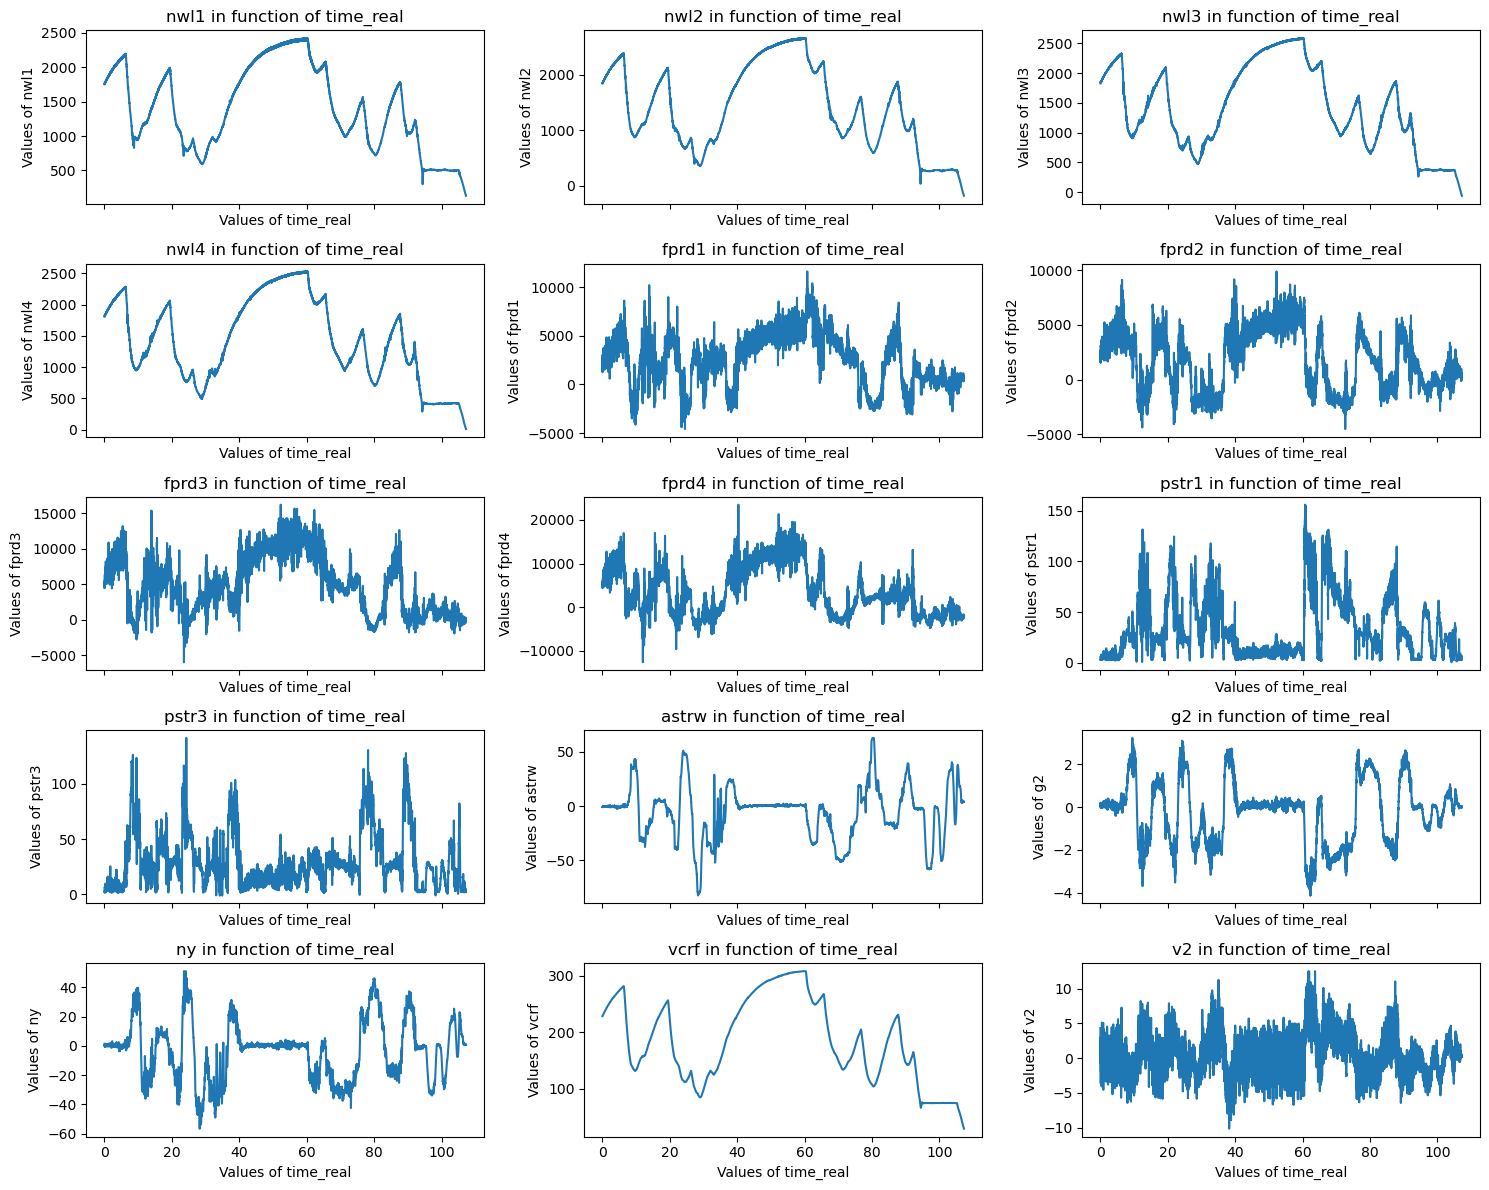

In [79]:

df = data_dict2[anomalous_sessions2[11]].copy()
df = preprocessing.clean_dataframe(df)
cols = df.columns[1:-1]
visualisation_plot(df, cols)

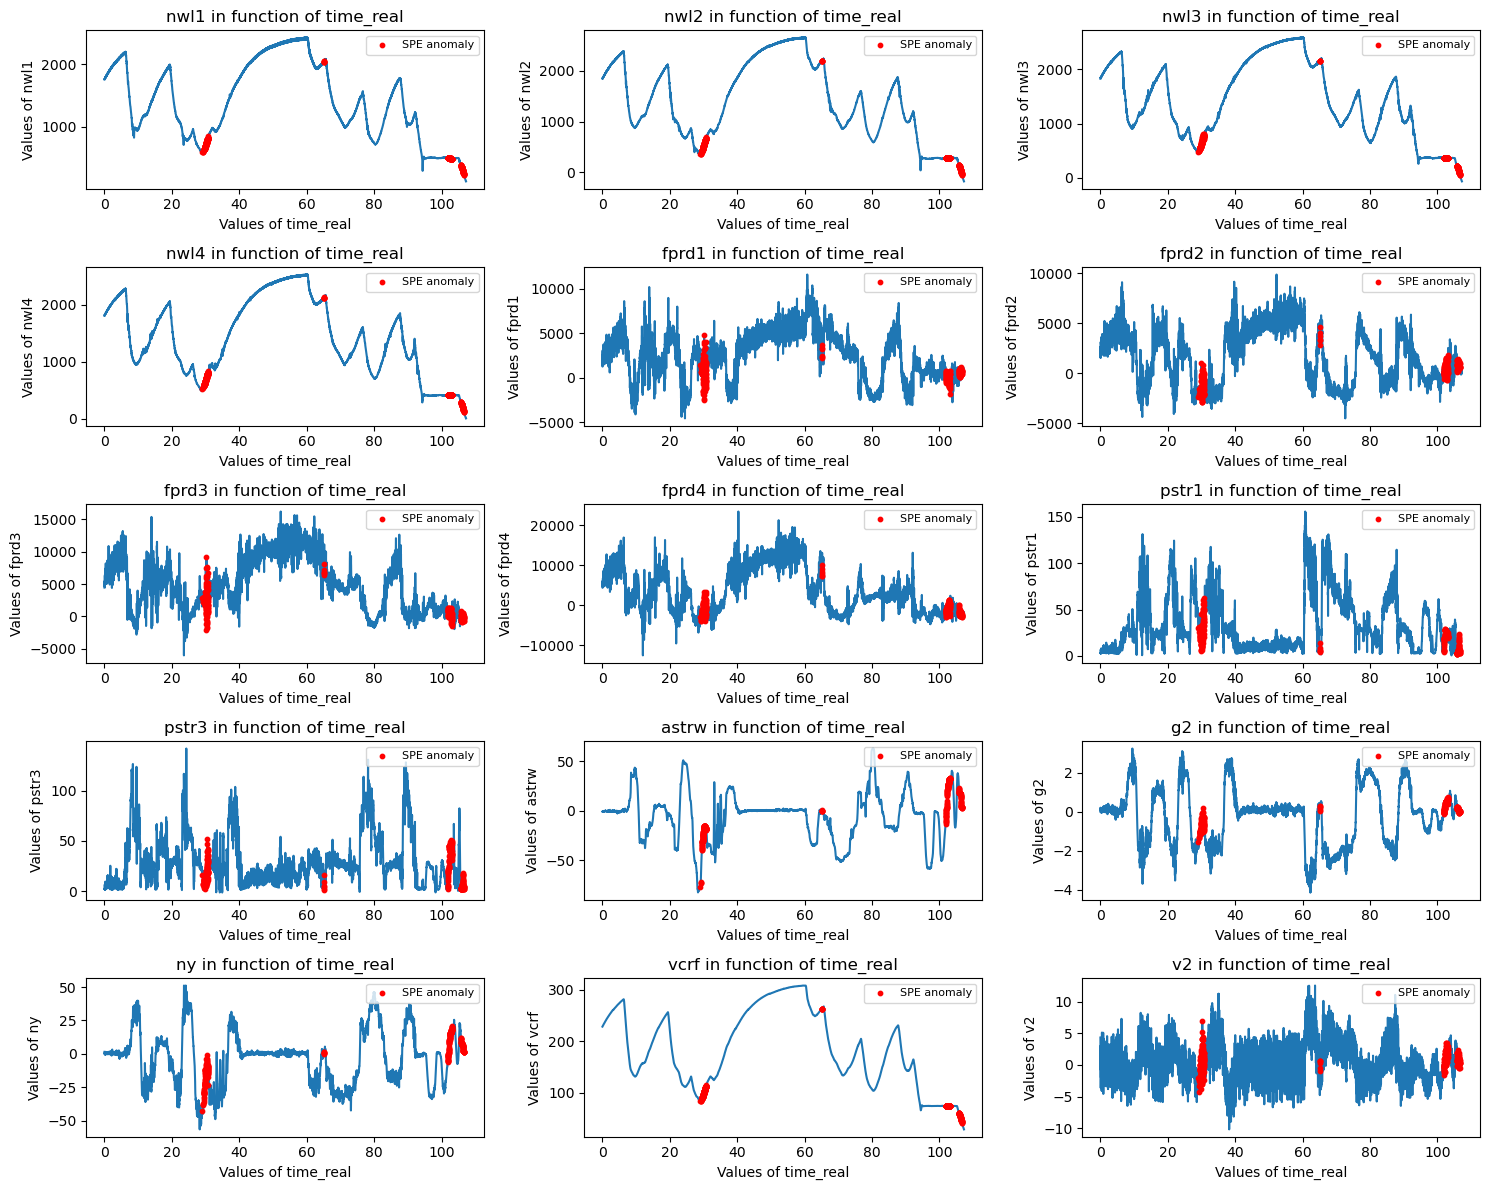

In [80]:
anomaly_mask  = clf_glob.predict_anomalies(data_dict2[anomalous_sessions2[21]])["anomaly_detected"]==1
visualisation_anomalies(df, anomaly_mask, cols, method="IF")